In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import re
import warnings
from numpy import mean
warnings.filterwarnings("ignore")


In [54]:
import numpy as np
import bisect

# 参数设置
N = 5000000
s = 0.99

k_all = np.arange(1, N + 1, dtype=np.float64)
H_N = np.sum(1.0 / k_all**s)
cumulative_probs = np.cumsum((1.0 / k_all**s) / H_N)

thresholds = [0.23, 0.38, 0.53, 0.65, 0.75, 0.83, 0.90, 0.95, 0.98]

table = []
prev_prob = 0.0
prev_k = 0

for target in thresholds:
    idx = bisect.bisect_left(cumulative_probs, target)
    k_threshold = idx + 1
    
    if idx >= N:
        k_threshold = N
    
    weight = int(round((target - prev_prob) * 100))
    start_k = prev_k + 1
    end_k = k_threshold
    
    table.append([weight, start_k, end_k])
    
    prev_prob = target
    prev_k = end_k

if prev_prob < 1.0:
    weight = int(round((1.0 - prev_prob) * 100))
    start_k = prev_k + 1
    end_k = N
    table.append([weight, start_k, end_k])

output = "set $fileidx = randvar(type=tabular, randtable={\n"
for row in table:
    output += f"{{{row[0]}, {row[1]}, {row[2]}}},\n"
output = output.rstrip(",\n") + "\n})"
print(output)

set $fileidx = randvar(type=tabular, randtable={
{23, 1, 28},
{15, 29, 333},
{15, 334, 3719},
{12, 3720, 24595},
{10, 24596, 115590},
{8, 115591, 391916},
{7, 391917, 1127010},
{5, 1127011, 2380421},
{3, 2380422, 3718181},
{2, 3718182, 5000000}
})


In [3]:
def convert_from_b(value):
    unit_to_bytes = {
        'B': 1,
        'KB': 1024,
        'MB': 1024 ** 2,
        'GB': 1024 ** 3,
        'TB': 1024 ** 4,
        'PB': 1024 ** 5,
    }
    base_vals = []
    for t, val, u in value:
        if u not in unit_to_bytes:
            continue
        base_vals.append(val * unit_to_bytes[u])
    if not base_vals:
        return value
    max_base = max(base_vals)
    for cand in ['PB', 'TB', 'GB', 'MB', 'KB', 'B']:
        if max_base / unit_to_bytes[cand] >= 1:
            chosen = cand
            break
    new_val = []
    for t, val, u in value:
        new_val.append((t, val * unit_to_bytes[u] / unit_to_bytes[chosen], chosen))
    return new_val

def read_log_file(filepath, name, convert):
    with open(filepath, 'r', errors='ignore') as file:
        lines = file.readlines()
    
    data = []
    for line in lines:
        if name in line:
            match = re.search(r"\[(\d{2}:\d{2}:\d{2})\.\d{6} \+\d{2}:\d{2}\] .* " + 
                    name + " = (\d+(?:\.\d{2})?)\s*(B|KB|MB|GB|TB|PB|EB)?", line)
            if match and match.group(1):
                time = match.group(1)
                value = float(match.group(2))
                unit = match.group(3) if match.group(3) else 'B' 
                data.append((time, value, unit))
    if (convert):
        return convert_from_b(data)
    
    return data

def convert_from_num(value):
    unit_to_num = {
        '1': 1,
        '10^3': 1000,
        '10^6': 1000 ** 2,
        '10^9': 1000 ** 3,
        '10^12': 1000 ** 4,
        '10^15': 1000 ** 5,
    }
    base_vals = []
    for t, val, u in value:
        if u not in unit_to_num:
            continue
        base_vals.append(val * unit_to_num[u])
    if not base_vals:
        return value
    max_base = max(base_vals)
    for cand in ['10^15', '10^12', '10^9', '10^6', '10^3', '1']:
        if max_base / unit_to_num[cand] >= 1:
            chosen = cand
            break
    new_val = []
    for t, val, u in value:
        new_val.append((t, val * unit_to_num[u] / unit_to_num[chosen], chosen))
    return new_val

def read_log_file2(filepath, name, convert):
    with open(filepath, 'r', errors='ignore') as file:
        lines = file.readlines()
    
    data = []
    for line in lines:
        if name in line:
            match = re.search(r"\[(\d{2}:\d{2}:\d{2})\.\d{6} \+\d{2}:\d{2}\] .* " + 
                    name + " = (\d+(?:\.\d{2})?)\s*(10\^3|10\^6|10\^9|10\^12)?", line)
            if match and match.group(1):
                time = match.group(1)
                value = float(match.group(2))
                unit = match.group(3) if match.group(3) else '1' 
                data.append((time, value, unit))
    if (convert):
        return convert_from_num(data)
    return data

# 每个名字每个文件一条线
def each_name_each_file(filepaths, names, unit = 'B', convert = True, exclude = 0, second = 0):
    for name in names:
        plt.figure(figsize=(10, 5), dpi=100)
        new_unit = 'B'
        for filepath in filepaths:
            if (unit == 'B'):
                data = read_log_file(filepath, name, convert)
            elif (unit == '1'):
                data = read_log_file2(filepath, name, convert)
            df = pd.DataFrame(data, columns=['Time', 'Space', 'Unit'])
            new_unit = df['Unit'].iloc[0] if not df['Unit'].isnull().all() else new_unit
            df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S')
            df['Time'] = df['Time'] - pd.Timedelta(seconds=second)
            df['Time'] = df['Time'].dt.floor('10S')
            df = df.drop_duplicates(subset=['Time'], keep='first')
            df = df.iloc[exclude:]
            plt.plot(df['Time'], df['Space'], marker='o', markersize=3, label=f'{filepath[filepath.rfind("-")-4:filepath.rfind("-")+2]}')
            print("Mean:", filepath[filepath.rfind("-")-4:filepath.rfind("-")+2], df['Space'].mean())
            print("Sum:", filepath[filepath.rfind("-")-4:filepath.rfind("-")+2], df['Space'].sum())
        
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
        plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
        plt.title(f'{name} over Time')
        plt.xlabel('Time')
        plt.ylabel(f"{new_unit}")
        plt.grid(True)
        plt.xticks(rotation=45)
        plt.legend()
        plt.tight_layout()
        plt.show()

# 每个名字多个文件求和一条线
def each_name_sum_file(filepaths, names, unit = 'B', convert = True, exclude = 0, second = 0):
    plt.figure(figsize=(10, 5), dpi=100)
    new_unit = 'B'
    for name in names:
        data_sum = pd.DataFrame(columns=['Time', 'Space'])
        for filepath in filepaths:
            if (unit == 'B'):
                data = read_log_file(filepath, name, convert)
            elif (unit == '1'):
                data = read_log_file2(filepath, name, convert)
            df = pd.DataFrame(data, columns=['Time', 'Space', 'Unit'])
            new_unit = df['Unit'].iloc[0] if not df['Unit'].isnull().all() else new_unit
            df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S')
            df['Time'] = df['Time'] - pd.Timedelta(seconds=second)
            df['Time'] = df['Time'].dt.floor('10S')
            df = df.drop_duplicates(subset=['Time'], keep='first')
            df = df.iloc[exclude:]
            data_sum = pd.concat([data_sum, df])
        data_sum['Space'] = data_sum['Space'].astype(float)  # 确保Space列是数值类型
        data_sum = data_sum.groupby(data_sum['Time']).sum().reset_index()
        plt.plot(data_sum['Time'], data_sum['Space'], marker='o', markersize=3, label=name)
        print("Final:", name, sum(list(data_sum['Space'])))
        
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.title(f'Space over Time')
    plt.xlabel('Time')
    plt.ylabel(f"{new_unit}")
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 每个名字多个文件求平均一条线
def each_name_mean_file(filepaths, names, unit='B', convert=True, include=0, second=0, show_sum=False, show_mean = False):
    plt.figure(figsize=(10, 5), dpi=100)
    new_unit = 'B'

    for name in names:
        all_dfs = []
        for filepath in filepaths:
            if unit == 'B':
                data = read_log_file(filepath, name, convert)
            elif unit == '1':
                data = read_log_file2(filepath, name, convert)
            if not data:
                continue
            
            df = pd.DataFrame(data, columns=['Time', 'Space', 'Unit'])
            new_unit = df['Unit'].iloc[0] if not df['Unit'].isnull().all() else new_unit
            df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S')
            df['Time'] = df['Time'] - pd.Timedelta(seconds=second)
            df['Time'] = df['Time'].dt.floor('10S')
            df = df.drop_duplicates(subset=['Time'], keep='first')
            df = df[df['Space'] != 0]
            all_dfs.append(df)
            
        if all_dfs:
            combined_df = pd.concat(all_dfs)
            avg_df = combined_df.groupby('Time', as_index=False)['Space'].mean()
            if (include > 0):
                avg_df = avg_df.tail(include)

            label = f"{name}"
            plt.plot(avg_df['Time'], avg_df['Space'], marker='o', markersize=3, label=label)
            if show_sum:
                print("Sum:", name, sum(list(avg_df['Space'])))
            if show_mean:
                print("Mean:", name, mean(list(avg_df['Space'])))
    
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.title(f"All Metrics ({', '.join(names)}) over Time")
    plt.xlabel('Time')
    plt.ylabel(f"{new_unit}")
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [2]:
import re

def read_file(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()

    pattern = re.compile(r'^(.*?)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)$')
    data = {}
    parsing = False

    for line in lines:
        line = line.rstrip('\n')
        if line.startswith("SUMMARY rate"):
            data = {}   
            parsing = True
            continue
        if not parsing:
            continue
        match = pattern.match(line.strip())
        if match:
            operation = match.group(1).strip()
            mean_val = float(match.group(4))
            data[operation] = mean_val
    return data


## Results summary

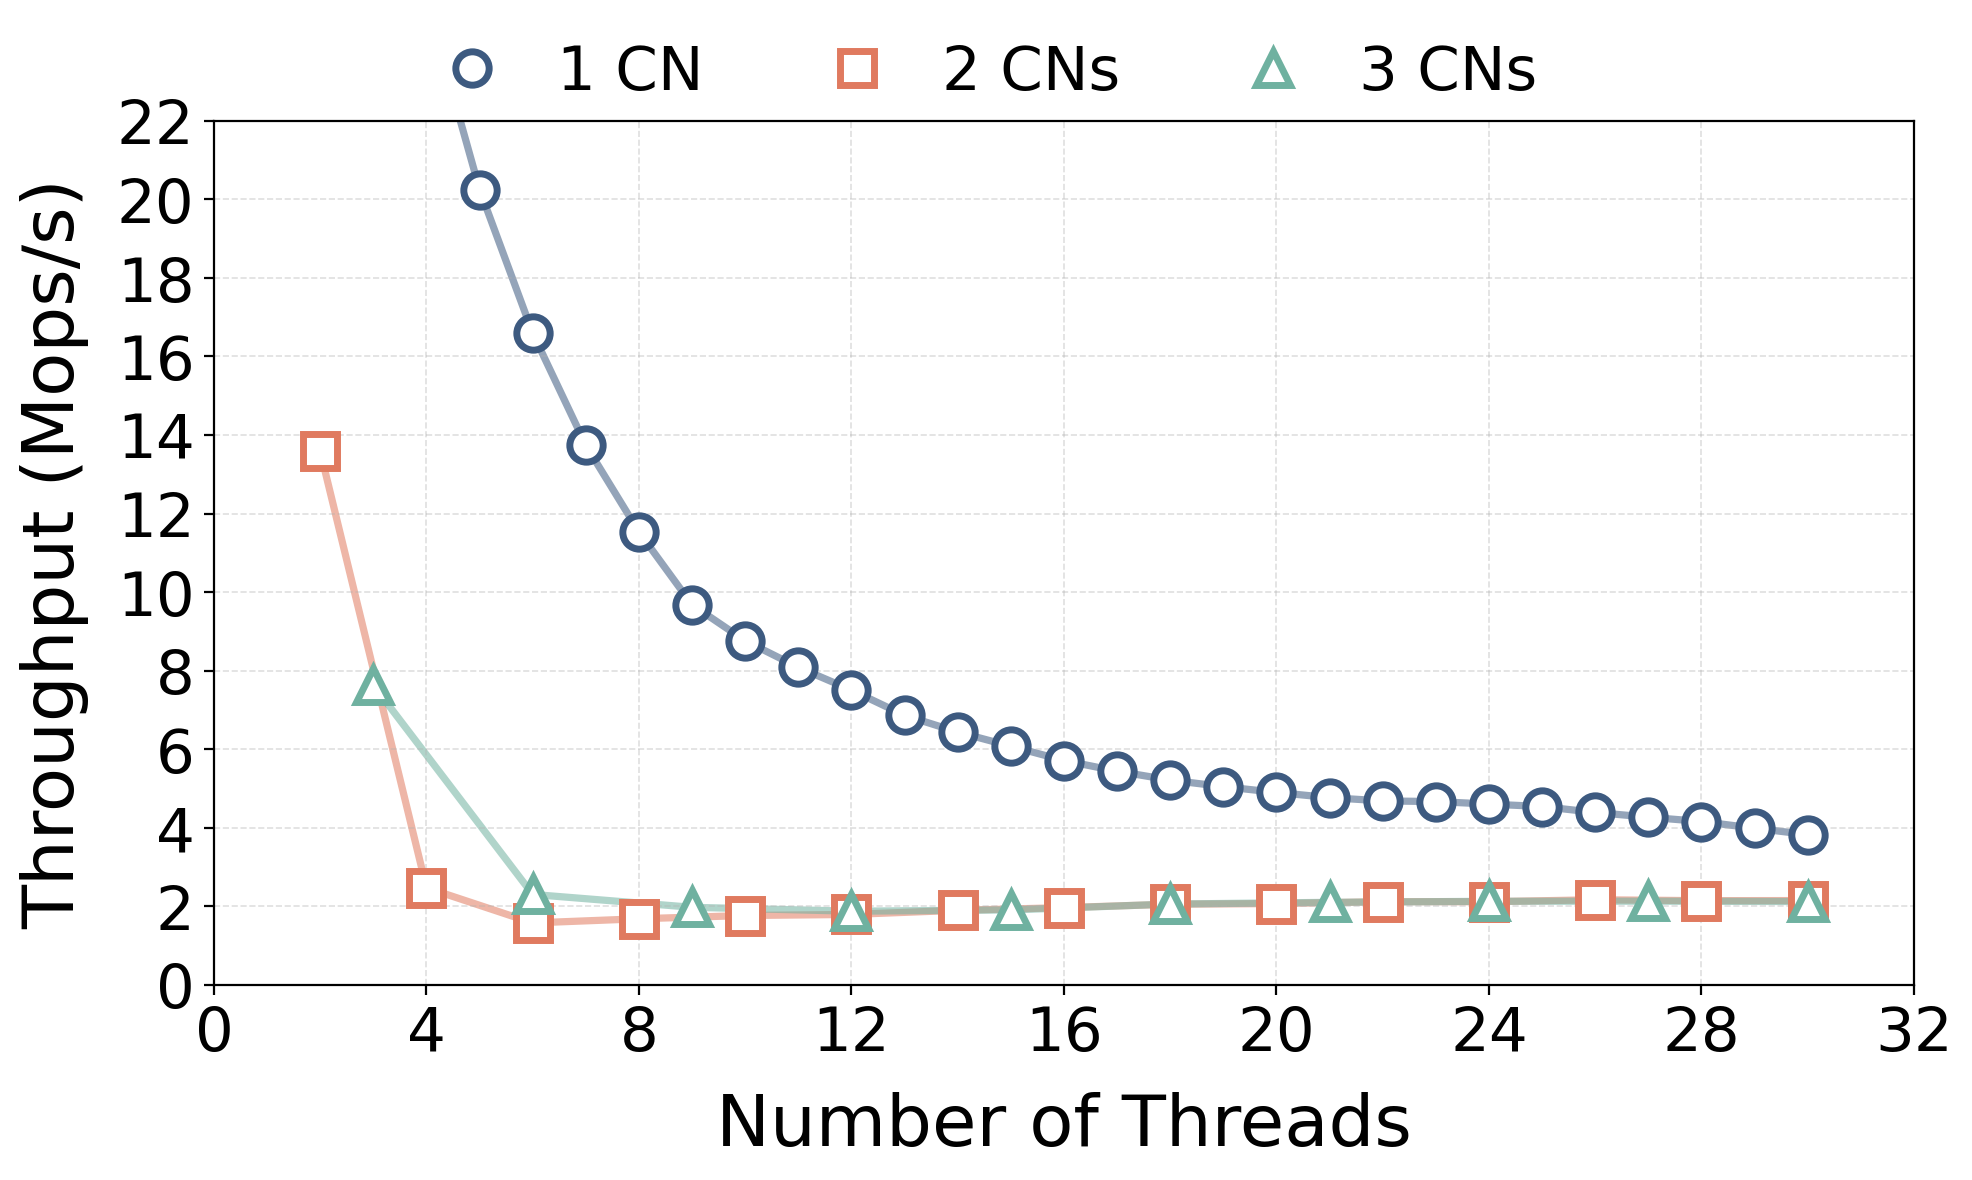

In [57]:
import re
import matplotlib.pyplot as plt

def extract_total_ops(log_file):
    total_ops_list = []
    with open(log_file, 'r') as f:
        for line in f:
            m = re.search(r'total_ops=(\d+)', line)
            if m:
                total_ops_list.append(int(m.group(1)))
    return total_ops_list

results = extract_total_ops("../test/cxl/cxl_lock_result.log")
results = [r / 10 for r in results]

threads = [i for i in range(1, 31)]
throughput_1CN = [r / 1e6 for r in results[0:30]]
throughput_2CN = [r / 1e6 for r in results[30:60]]
throughput_3CN = [r / 1e6 for r in results[60:90]]

threads_2 = [t for t in threads if t % 2 == 0]
throughput_2CN_mark = [throughput_2CN[t-1] for t in threads_2]

threads_3 = [t for t in threads if t % 3 == 0]
throughput_3CN_mark = [throughput_3CN[t-1] for t in threads_3]

# 配色与 cxl_read_write 图保持一致风格：冷色 / 暖色 / 中性
COLORS  = {'1 CN': '#3D5A80', '2 CNs': '#E07A5F', '3 CNs': '#6FB1A0'}
MARKERS = {'1 CN': 'o',       '2 CNs': 's',       '3 CNs': '^'}

fig, ax = plt.subplots(figsize=(10, 6), dpi=200)

def plot_curve(xs, ys, label):
    c = COLORS[label]
    m = MARKERS[label]
    # 半透明粗线托底
    ax.plot(xs, ys, '-', linewidth=2.6, color=c, alpha=0.55, zorder=1)
    # 白心彩边圆点：研究论文风格，避免 marker 把线遮住
    ax.plot(xs, ys, m, markersize=12, color=c,
            markerfacecolor='white', markeredgewidth=2.5,
            markeredgecolor=c, label=label, zorder=3,
            linestyle='None')

plot_curve(threads[1:],   throughput_1CN[1:],     '1 CN')
plot_curve(threads_2,     throughput_2CN_mark,    '2 CNs')
plot_curve(threads_3,     throughput_3CN_mark,    '3 CNs')

ax.set_xlabel('Number of Threads', fontsize=26, labelpad=10)
ax.set_ylabel('Throughput (Mops/s)', fontsize=26, labelpad=10)
ax.set_xlim(0, 32)
ax.set_ylim(0, 22)
ax.set_xticks(range(0, 33, 4))
ax.set_yticks(range(0, 23, 2))
ax.tick_params(axis='both', labelsize=22)
ax.grid(True, linestyle='--', linewidth=0.6, alpha=0.4)

# 单行 legend，放图上方居中（和 IOPS 图一致风格）
fig.legend(
    ncol=3, loc='upper center', bbox_to_anchor=(0.5, 0.99),
    frameon=False, fontsize=22,
    handletextpad=0.4, columnspacing=1.5,
)

plt.subplots_adjust(top=0.88, bottom=0.16, left=0.12, right=0.97)
plt.show()


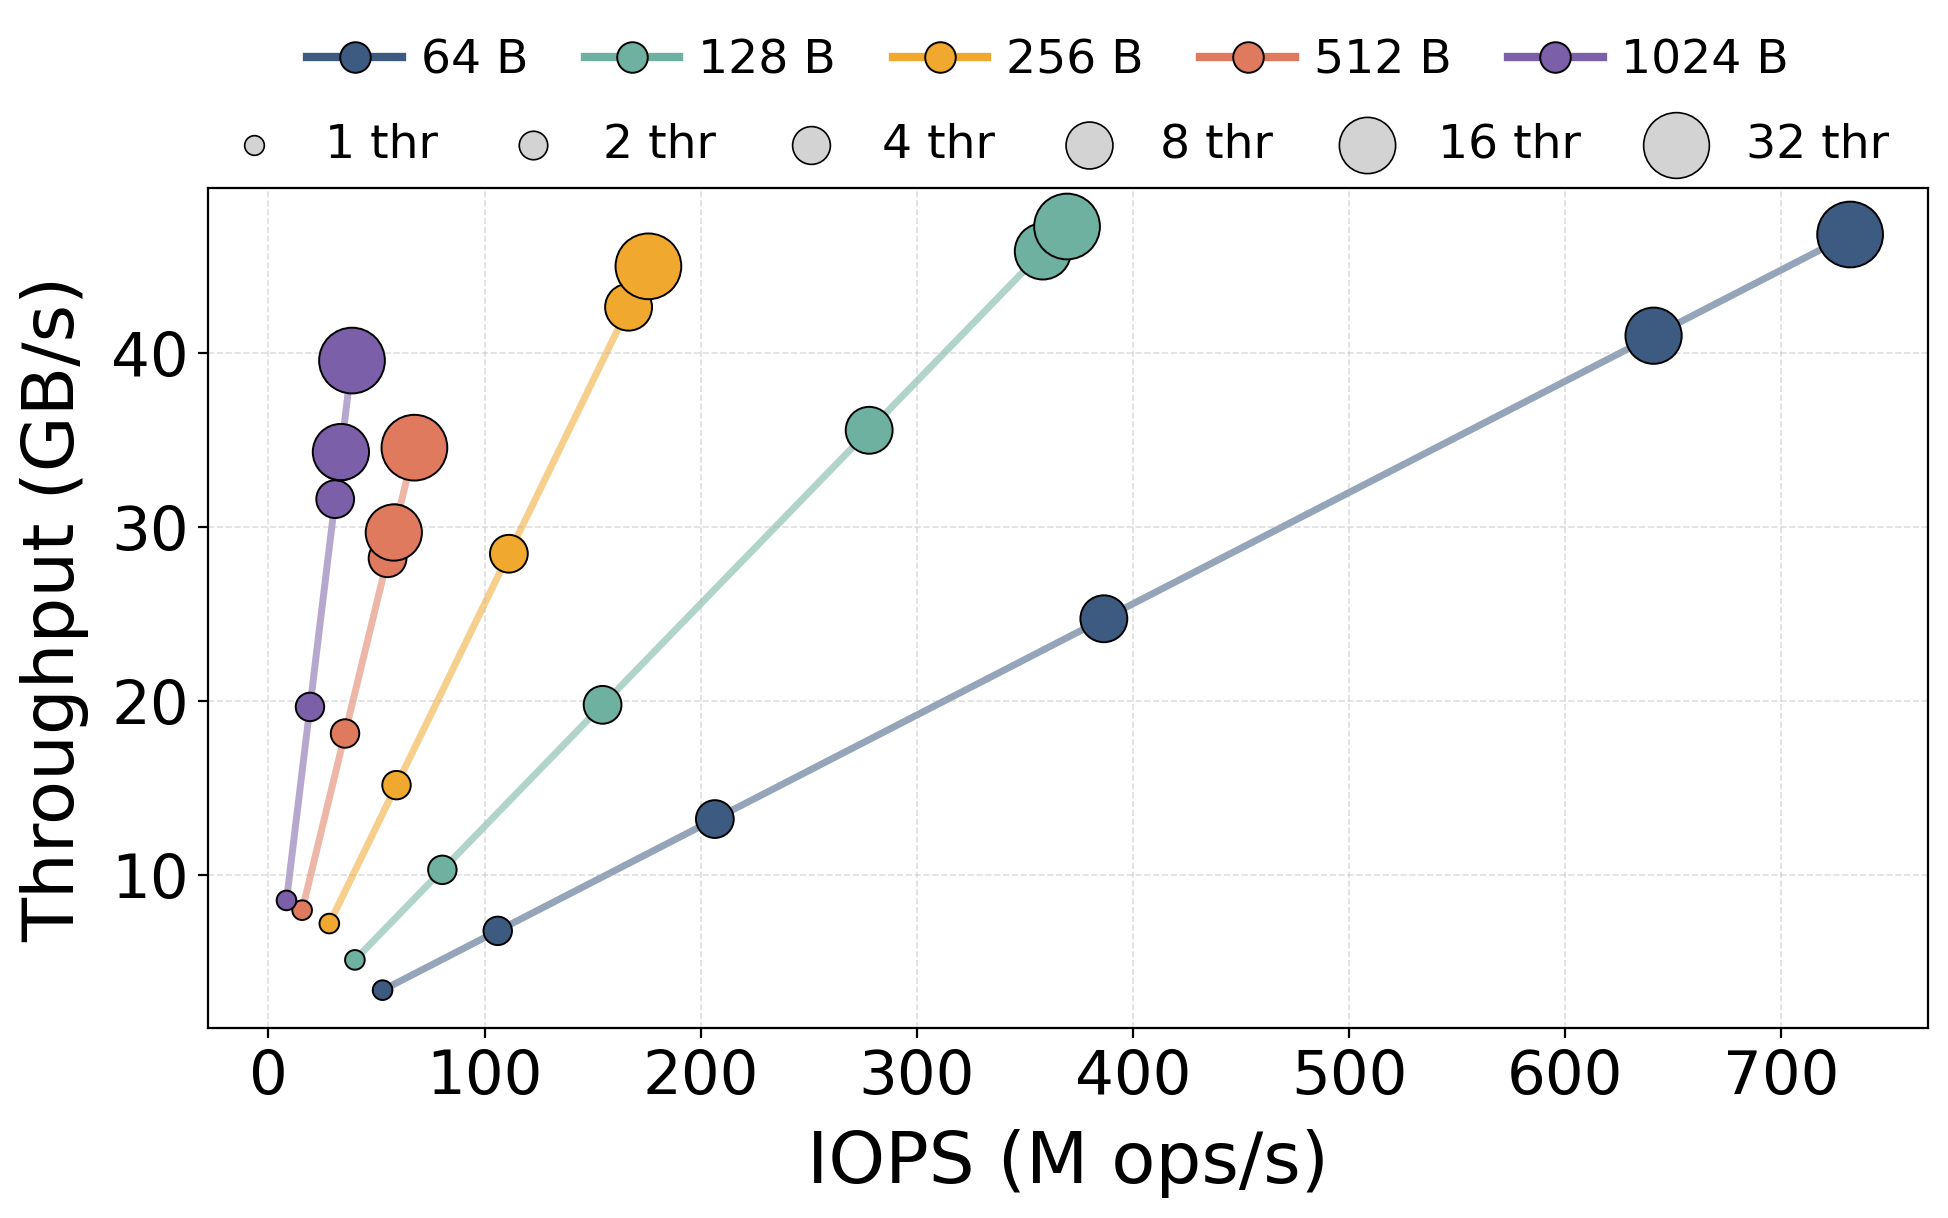

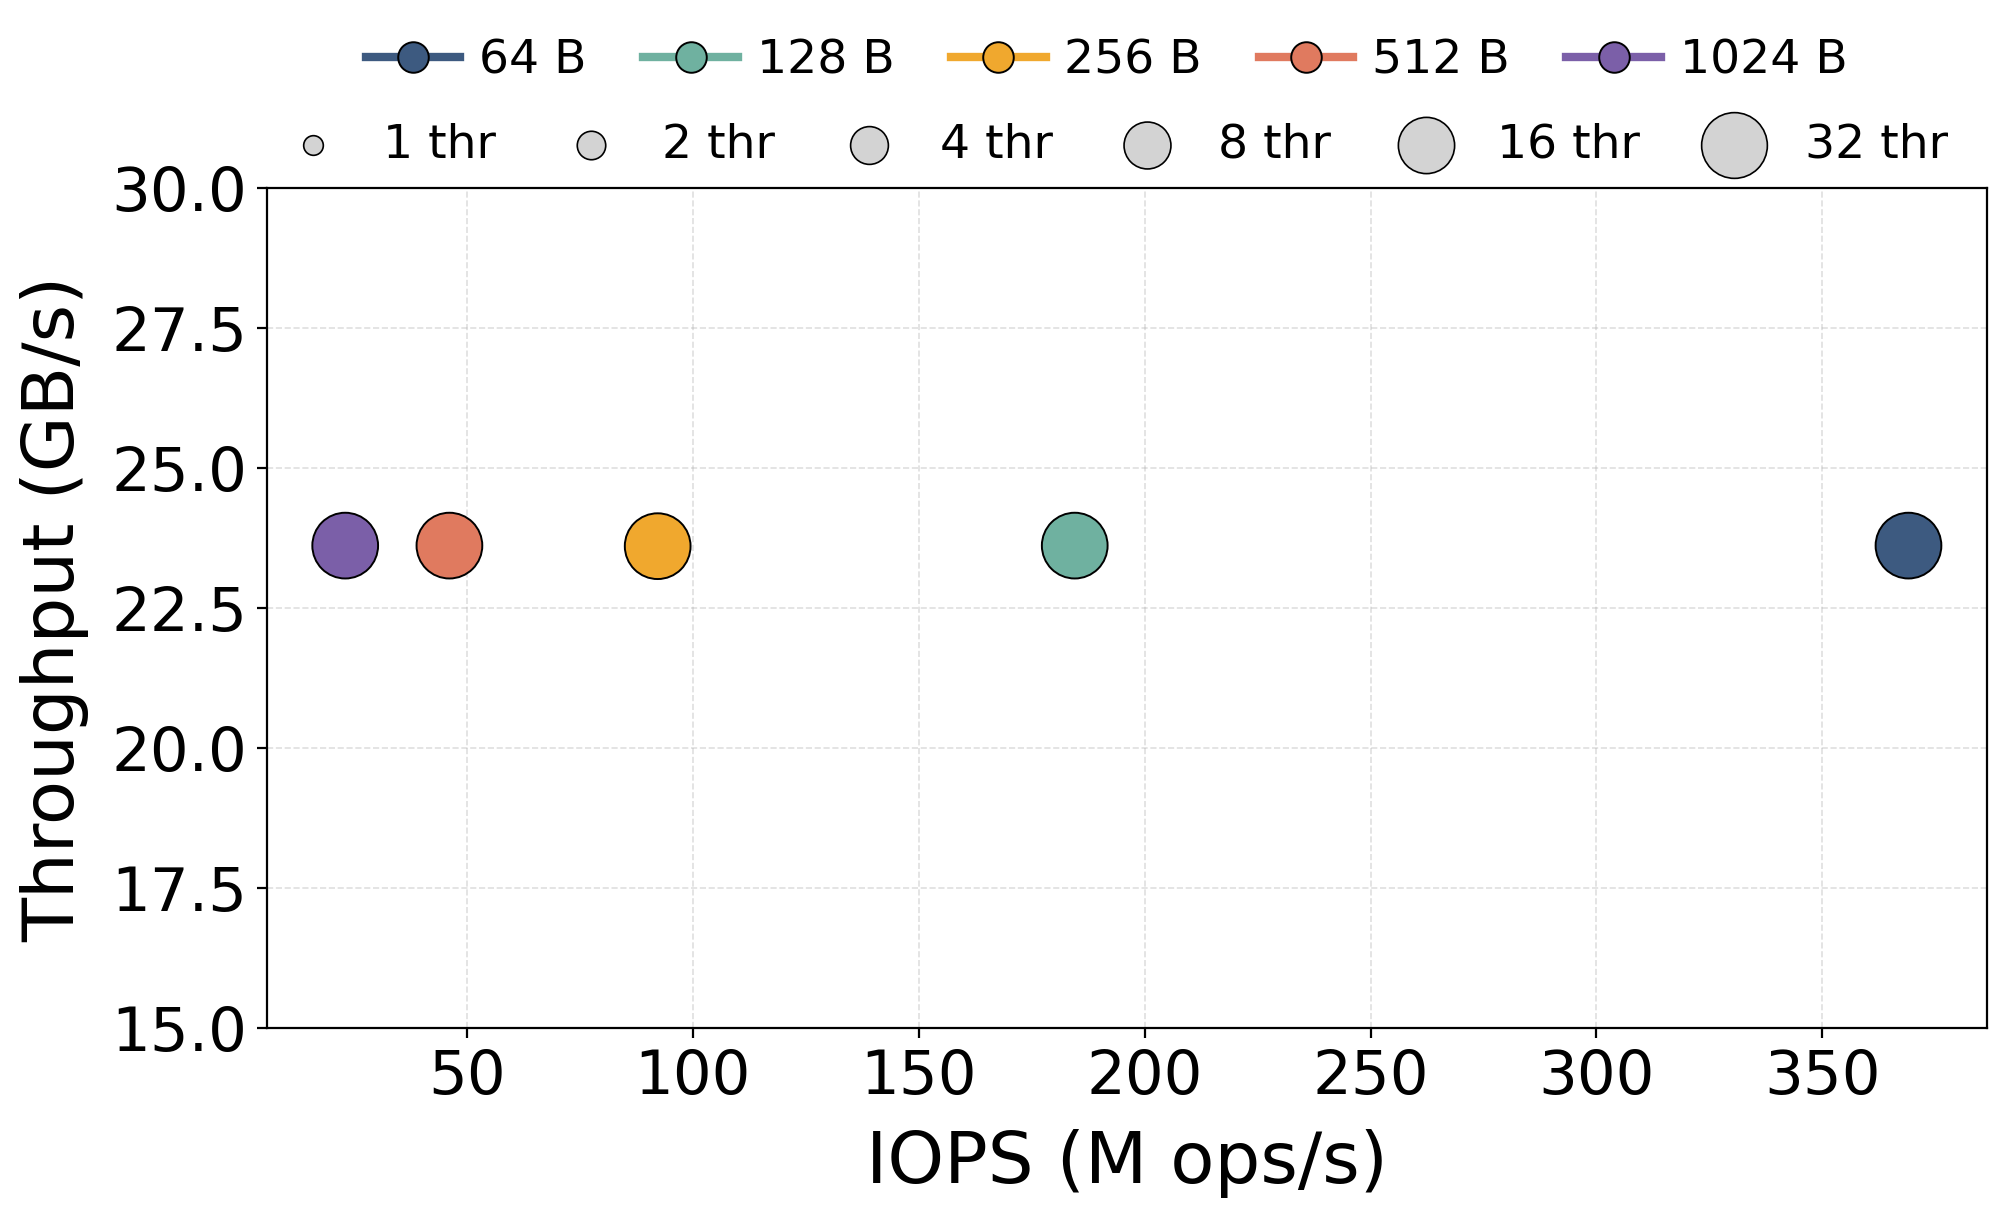

In [56]:
import re
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

LOG_FILE = "../test/cxl/cxl_read_write.log"

pattern = re.compile(
    r"\[threads=\s*(\d+), grain=\s*(\d+)B, (read|write)\] time=([0-9.]+)s, BW=([0-9.]+) GB/s"
)

records = []
text = Path(LOG_FILE).read_text(encoding="utf-8", errors="ignore")

for line in text.splitlines():
    m = pattern.search(line)
    if not m:
        continue
    records.append({
        "threads":  int(m.group(1)),
        "grain":    int(m.group(2)),
        "op":       m.group(3),
        "time_sec": float(m.group(4)),
        "bw":       float(m.group(5)),
        "iops":     float(m.group(5)) * 1000.0 / int(m.group(2)),
    })

records.sort(key=lambda r: (r["op"], r["grain"], r["threads"]))
grains       = sorted({r["grain"]   for r in records})
threads_list = sorted({r["threads"] for r in records})

# 双重编码：颜色 = 粒度，点大小 = 线程数。
GRAIN_COLORS = ['#3D5A80', '#6FB1A0', '#F0A82E', '#E07A5F', '#7B5FA8']
THREAD_SIZES = {1: 50, 2: 105, 4: 185, 8: 285, 16: 410, 32: 560}

def plot_for_op(op, ylim=None):
    fig, ax = plt.subplots(figsize=(10, 6), dpi=200)

    grain_handles = []
    for i, grain in enumerate(grains):
        xs, ys, ts = [], [], []
        for t in threads_list:
            for r in records:
                if r["op"] == op and r["grain"] == grain and r["threads"] == t:
                    xs.append(r["iops"]); ys.append(r["bw"]); ts.append(t); break
        if not xs:
            continue
        c = GRAIN_COLORS[i % len(GRAIN_COLORS)]
        ax.plot(xs, ys, '-', color=c, linewidth=2.5, alpha=0.55, zorder=1)
        ax.scatter(xs, ys, s=[THREAD_SIZES[t] for t in ts], color=c,
                   edgecolor='black', linewidth=0.7, zorder=2)
        grain_handles.append(
            Line2D([0], [0], color=c, lw=3, marker='o', markersize=11,
                   markeredgecolor='black', markeredgewidth=0.7,
                   label=f"{grain} B")
        )

    thread_handles = [
        plt.scatter([], [], s=THREAD_SIZES[t], color='lightgray',
                    edgecolor='black', linewidth=0.6, label=f"{t} thr")
        for t in threads_list
    ]

    # ax.set_xscale('log')
    ax.set_xlabel('IOPS (M ops/s)', fontsize=26, labelpad=8)
    ax.set_ylabel('Throughput (GB/s)', fontsize=26, labelpad=8)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.tick_params(axis='both', labelsize=22)
    ax.grid(True, linestyle='--', linewidth=0.6, alpha=0.4, which='both')

    fig.legend(
        handles=grain_handles, ncol=len(grains),
        loc='upper center', bbox_to_anchor=(0.53, 0.99),
        frameon=False, fontsize=17,
        handletextpad=0.4, columnspacing=1.2,
    )
    fig.legend(
        handles=thread_handles, ncol=len(threads_list),
        loc='upper center', bbox_to_anchor=(0.53, 0.92),
        frameon=False, fontsize=17,
        handletextpad=0.5, columnspacing=1.0,
        scatterpoints=1,
    )

    plt.subplots_adjust(top=0.83, bottom=0.13, left=0.11, right=0.97)
    plt.show()

plot_for_op("read")
plot_for_op("write", ylim=(15, 30))


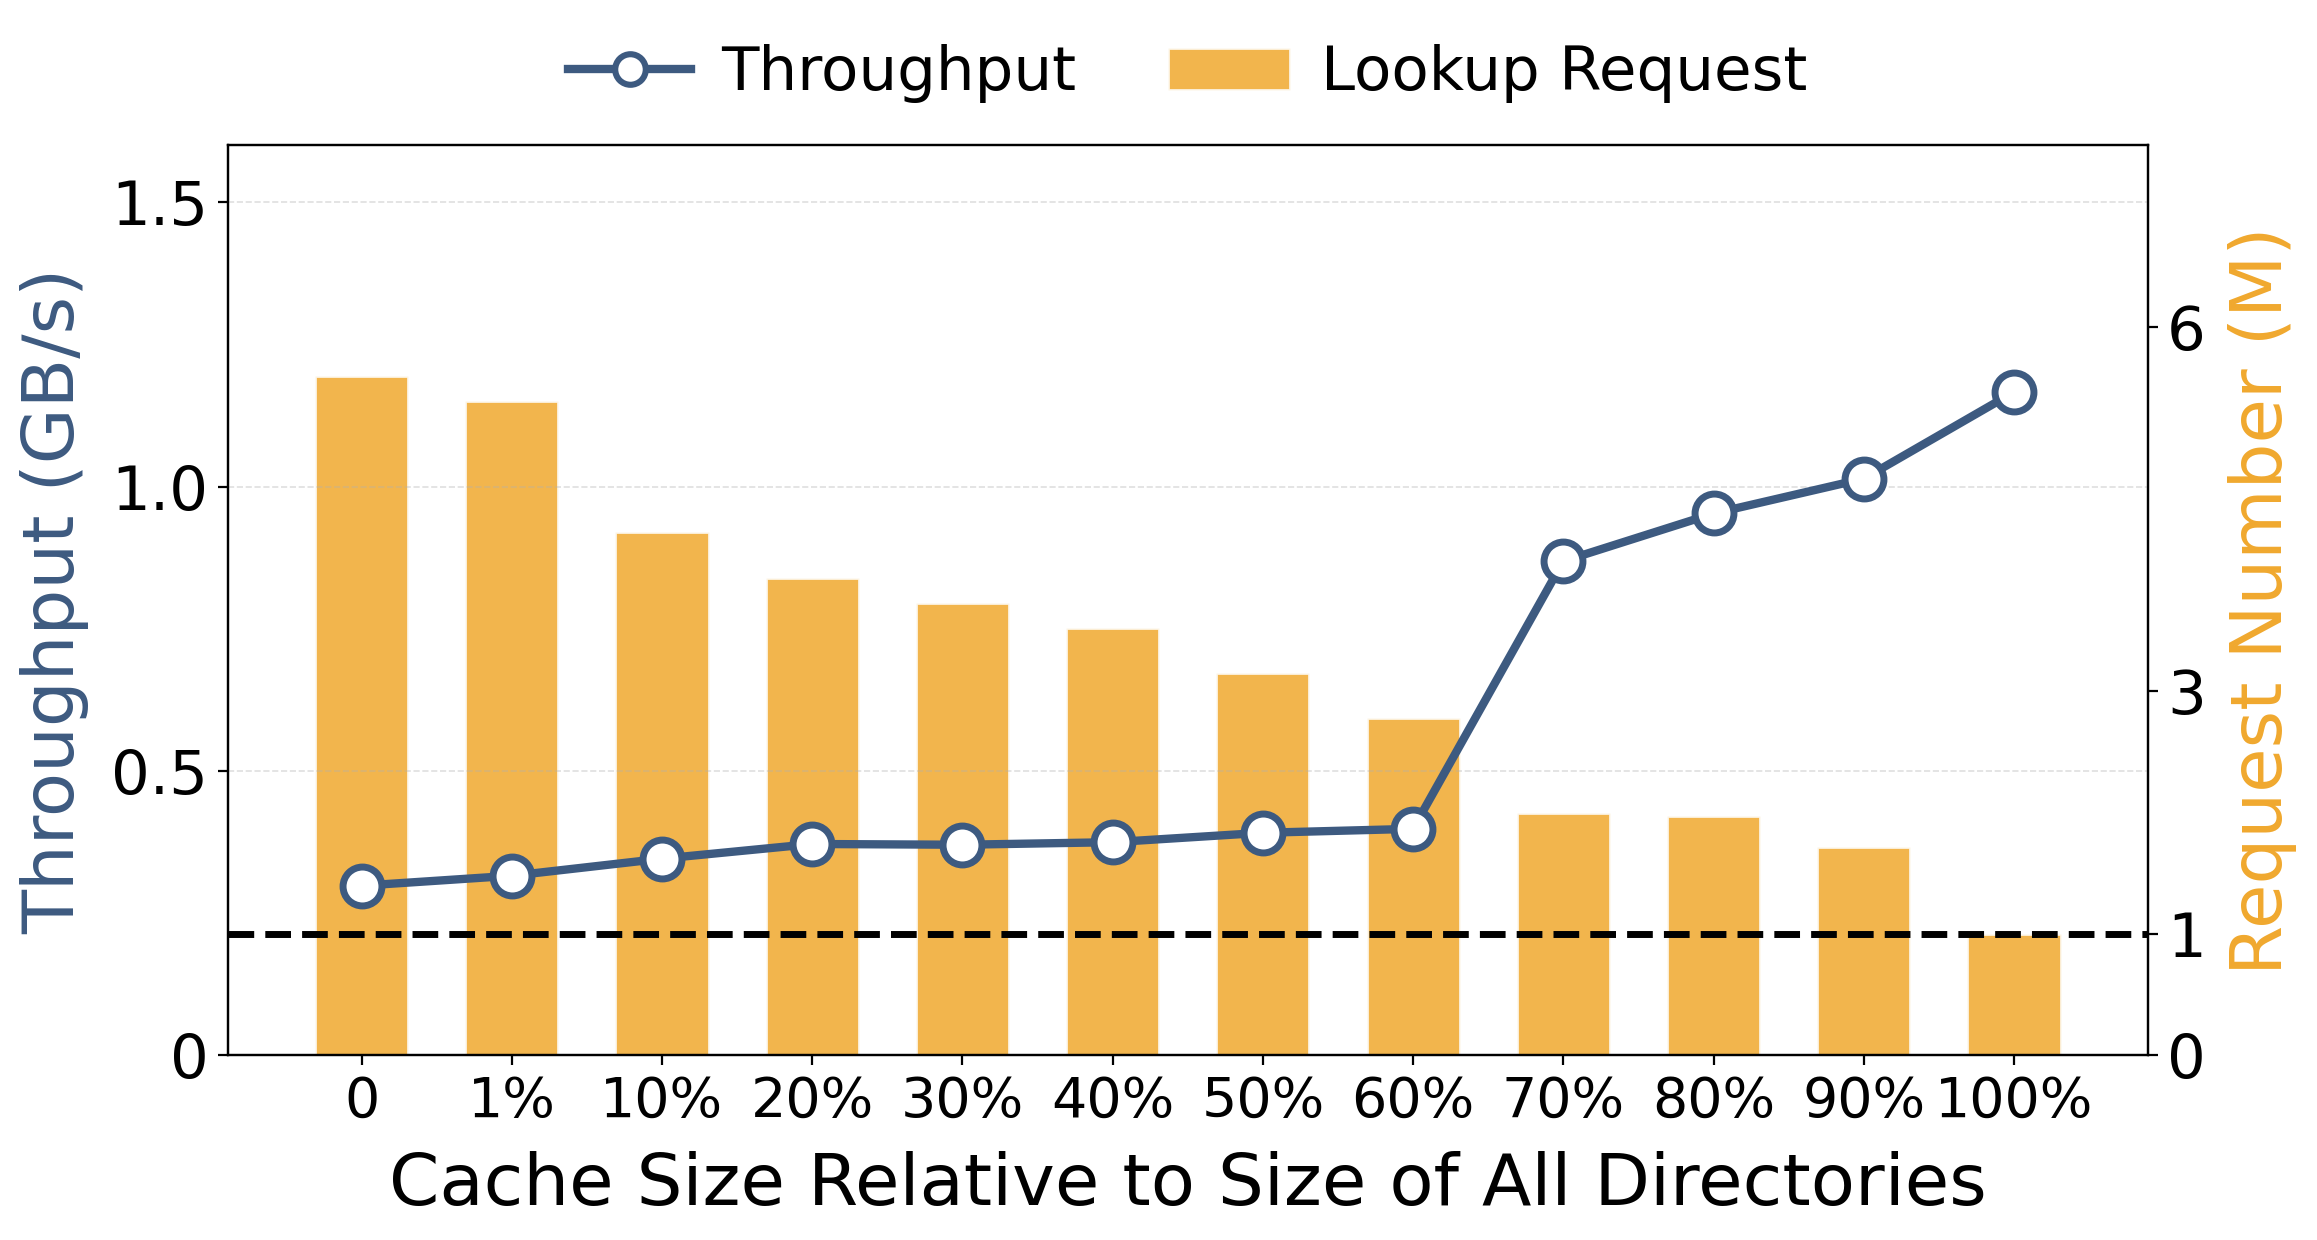

In [73]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

data = pd.read_excel('ceph_cache.xlsx')

threads = data.loc[:11, 'cache_size']
reqs = data.loc[:11, 'reqs']
reqs = [i + 100000 for i in reqs]
reqs = [i * 10 / 1000 / 1000 for i in reqs]
throughput = data.loc[:11, 'throughput']
throughput = [i * 5 / 1024 for i in throughput]

x_positions = np.arange(len(threads))

# 配色：throughput 用深蓝（主角），request 用淡灰柱（背景信息），
# threshold 用珊瑚红虚线（视觉锚点）。整体匹配 cxl_read_write 图风格。
COLOR_THR    = '#3D5A80'   # 深蓝 — throughput 折线
COLOR_REQ    = '#F0A82E'   # 暖黄 — request 柱（与深蓝高对比）
COLOR_LINE   = 'black' 

fig, ax1 = plt.subplots(figsize=(12, 6.5), dpi=200)

# ---- 左轴：throughput 折线 ----
line_thr, = ax1.plot(
    x_positions, throughput,
    marker='o', markersize=14,
    markerfacecolor='white', markeredgewidth=2.5,
    markeredgecolor=COLOR_THR,
    linewidth=3.0, color=COLOR_THR,
    label='Throughput', zorder=5,
)
ax1.set_yticks([0, 0.5, 1, 1.5])
ax1.set_yticklabels(['0', '0.5', '1.0', '1.5'])
ax1.set_ylim(0, 1.6)
ax1.set_xlabel('Cache Size Relative to Size of All Directories', fontsize=26, labelpad=8)
ax1.set_ylabel('Throughput (GB/s)', fontsize=26, labelpad=8, color=COLOR_THR)
ax1.tick_params(axis='y', labelsize=22)
ax1.tick_params(axis='x', labelsize=20)
ax1.set_xticks(x_positions)
ax1.set_xticklabels(threads)
ax1.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.4)

# ---- 右轴：request 柱状 ----
ax2 = ax1.twinx()
ax2.set_zorder(1)
ax1.set_zorder(2)
ax1.patch.set_visible(False)

threshold = 1
bars = ax2.bar(
    x_positions, reqs,
    color=COLOR_REQ, alpha=0.85, width=0.62,
    edgecolor='white', linewidth=1.0,
    label='Lookup Request', zorder=1,
)

ax2.set_ylabel('Request Number (M)', fontsize=26, labelpad=8, color=COLOR_REQ)
ax2.tick_params(axis='y', labelsize=22)
ax2.set_yticks([0, 1, 3, 6])
ax2.set_ylim(0, 7.5)

# threshold 横线 + 文字标注（Threshold = 1M req）
line_thresh = ax2.axhline(
    y=threshold, color=COLOR_LINE, linestyle='--', linewidth=2.5,
    zorder=4, label='Threshold (1M)',
)

# ---- 单行图例放图上方居中 ----
legend_handles = [
    Line2D([0], [0], color=COLOR_THR, lw=3, marker='o', markersize=11,
           markerfacecolor='white', markeredgewidth=2.2,
           markeredgecolor=COLOR_THR, label='Throughput'),
    Patch(facecolor=COLOR_REQ, edgecolor='white', alpha=0.85,
          label='Lookup Request'),
]
fig.legend(
    handles=legend_handles, ncol=3,
    loc='upper center', bbox_to_anchor=(0.5, 0.98),
    frameon=False, fontsize=22,
    handletextpad=0.5, columnspacing=1.5,
)

plt.subplots_adjust(top=0.86, bottom=0.16, left=0.10, right=0.90)
plt.show()


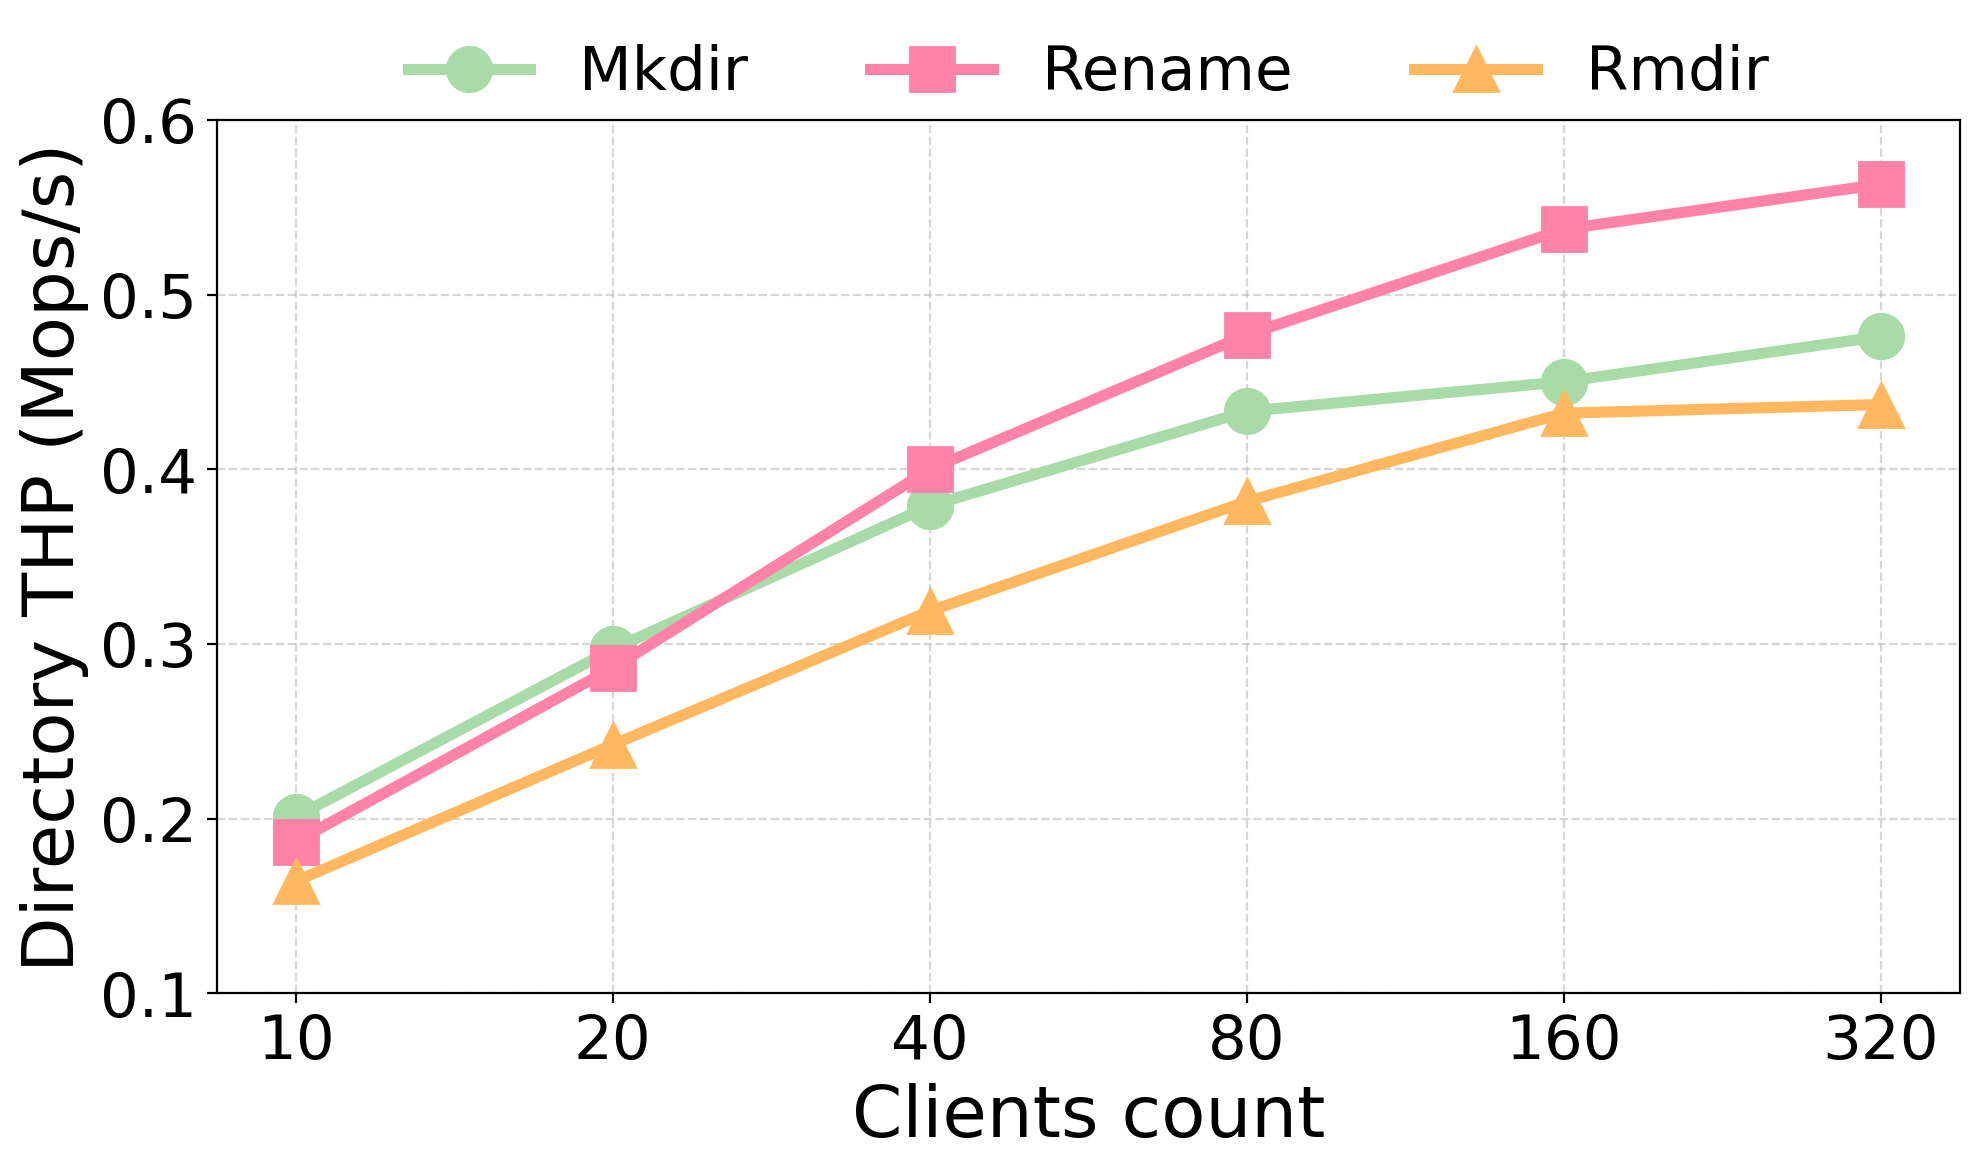

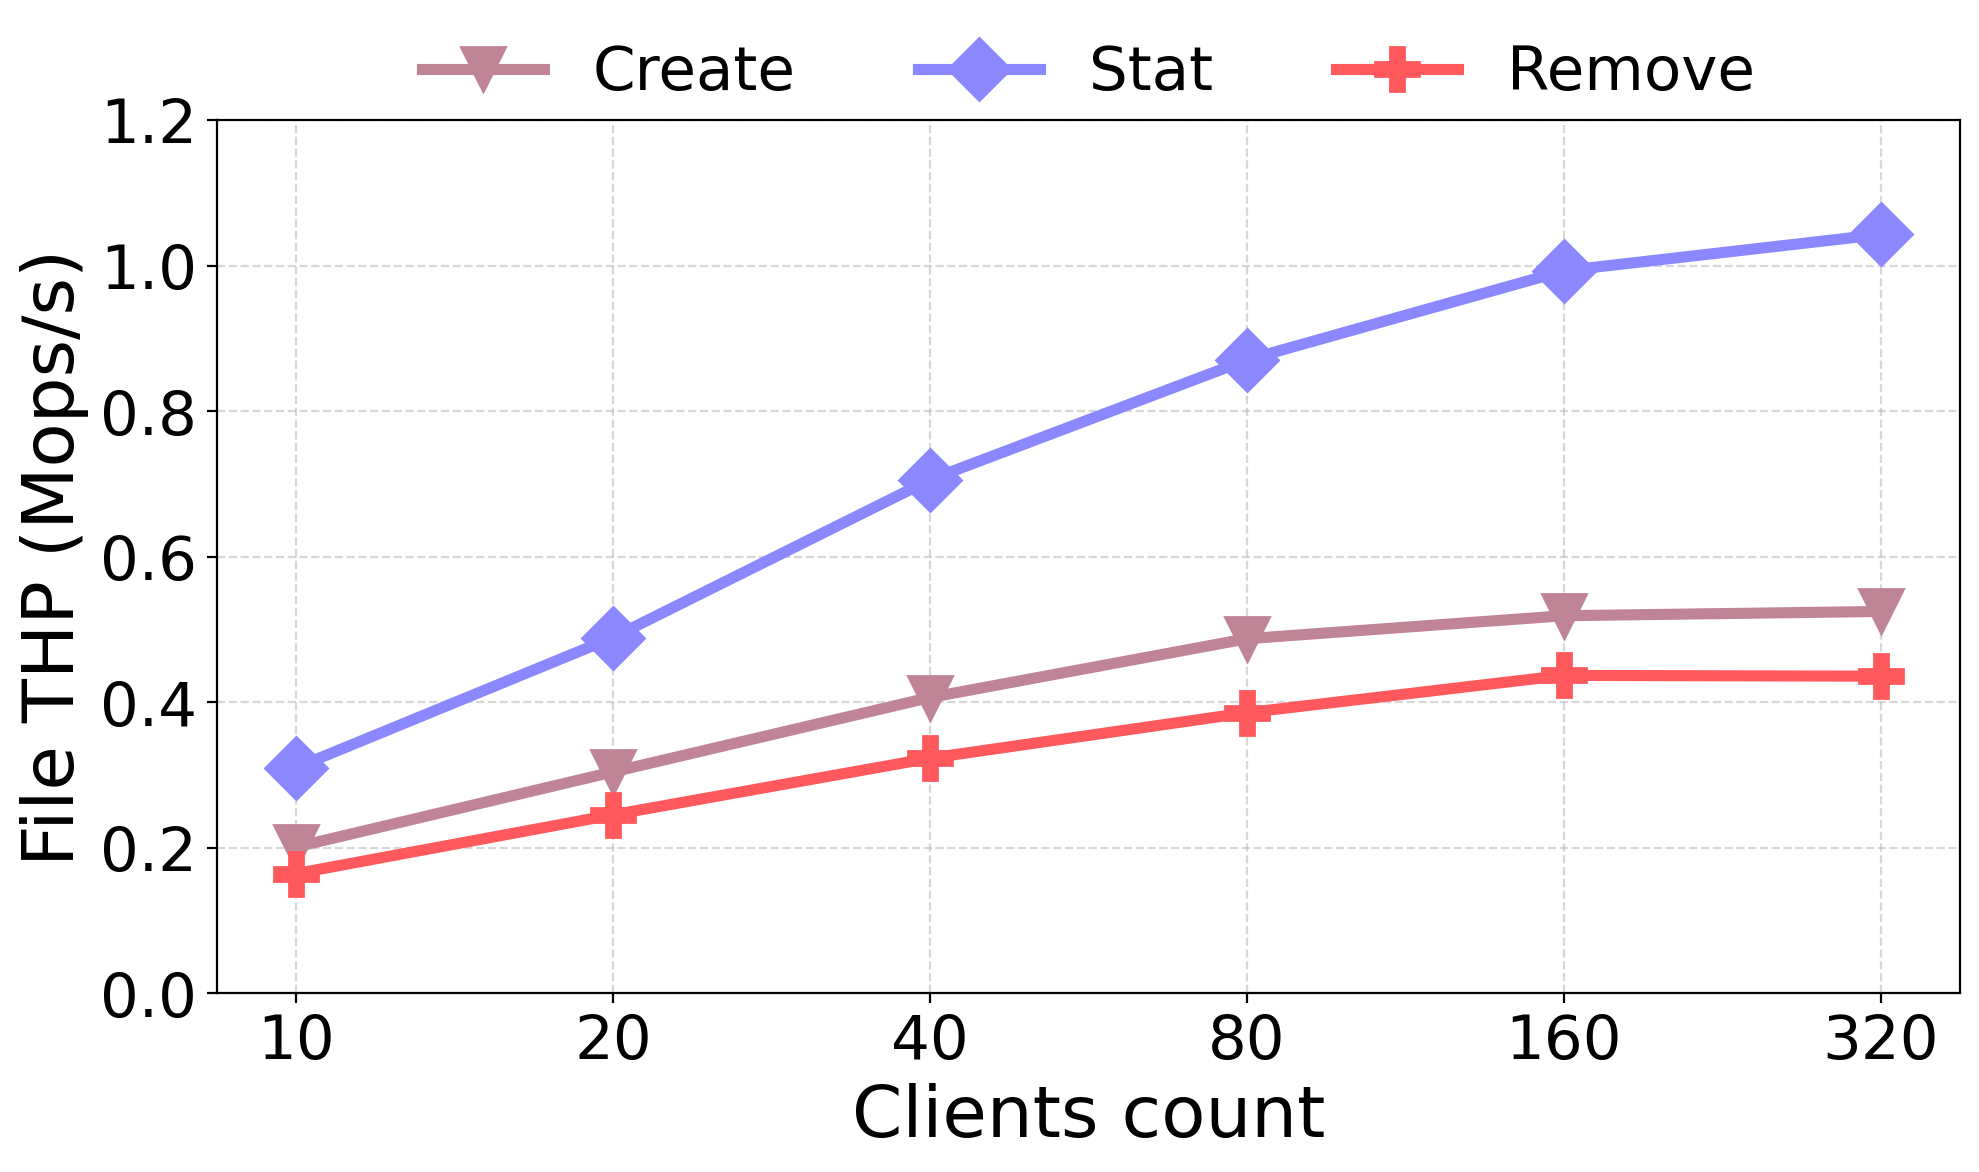

In [83]:
import matplotlib.pyplot as plt

data2 = read_file("../mdtest_5_2_3_8.log")
data4 = read_file("../mdtest_5_4_3_8.log")
data8 = read_file("../mdtest_5_8_3_8.log")
data16 = read_file("../mdtest_5_16_3_8.log")
data32 = read_file("../mdtest_5_32_3_8.log")
data64 = read_file("../mdtest_5_64_3_8.log")

datasets = [data2, data4, data8, data16, data32, data64]
x_values = [i * 5 for i in [2, 4, 8, 16, 32, 64]]
x_pos = range(len(x_values))

operations = ['Directory creation', 'Directory rename', 'Directory removal']
labels = ['Mkdir', 'Rename', 'Rmdir']

operations2 = ['File creation', 'File stat', 'File removal']
labels2 = ['Create', 'Stat', 'Remove']

colors = ['#a8dba8', '#FF82A9', '#FFB85F', '#C08497', '#8B88FF', '#ff595e']
markers = ['o', 's', '^', 'v', 'D', 'P']

plt.figure(figsize=(10, 6), dpi=200)

handles1 = []

for i in range(len(operations)):
    y_values = [d[operations[i]] / 1_000_000 for d in datasets]

    h, = plt.plot(
        x_pos, y_values,
        marker=markers[i],
        label=labels[i],
        markersize=16,
        linewidth=4,
        color=colors[i]
    )
    handles1.append(h)

plt.xticks(x_pos, x_values, fontsize=22)
plt.yticks(fontsize=22)
plt.ylim(0.1, 0.6)
plt.xlabel("Clients count", fontsize=26)
plt.ylabel("Directory THP (Mops/s)", fontsize=26)
plt.grid(linestyle="--", alpha=0.5)

plt.legend(
    handles1, labels,
    ncol=3,
    fontsize=22,
    loc='upper center',
    bbox_to_anchor=(0.5,1.15),
    frameon=False,
)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6), dpi=200)

handles2 = []

for i in range(len(operations2)):
    y_values = [d[operations2[i]] / 1_000_000 for d in datasets]

    h, = plt.plot(
        x_pos, y_values,
        marker=markers[i+3],
        label=labels2[i],
        markersize=16,
        linewidth=4,
        color=colors[i + 3]
    )
    handles2.append(h)

plt.xticks(x_pos, x_values, fontsize=22)
plt.yticks(fontsize=22)
plt.ylim(0, 1.2)
plt.xlabel("Clients count", fontsize=26)
plt.ylabel("File THP (Mops/s)", fontsize=26)
plt.grid(linestyle="--", alpha=0.5)

plt.legend(
    handles2, labels2,
    ncol=3,
    fontsize=22,
    loc='upper center',
    bbox_to_anchor=(0.5,1.15),
    frameon=False,
)

plt.tight_layout()
plt.show()


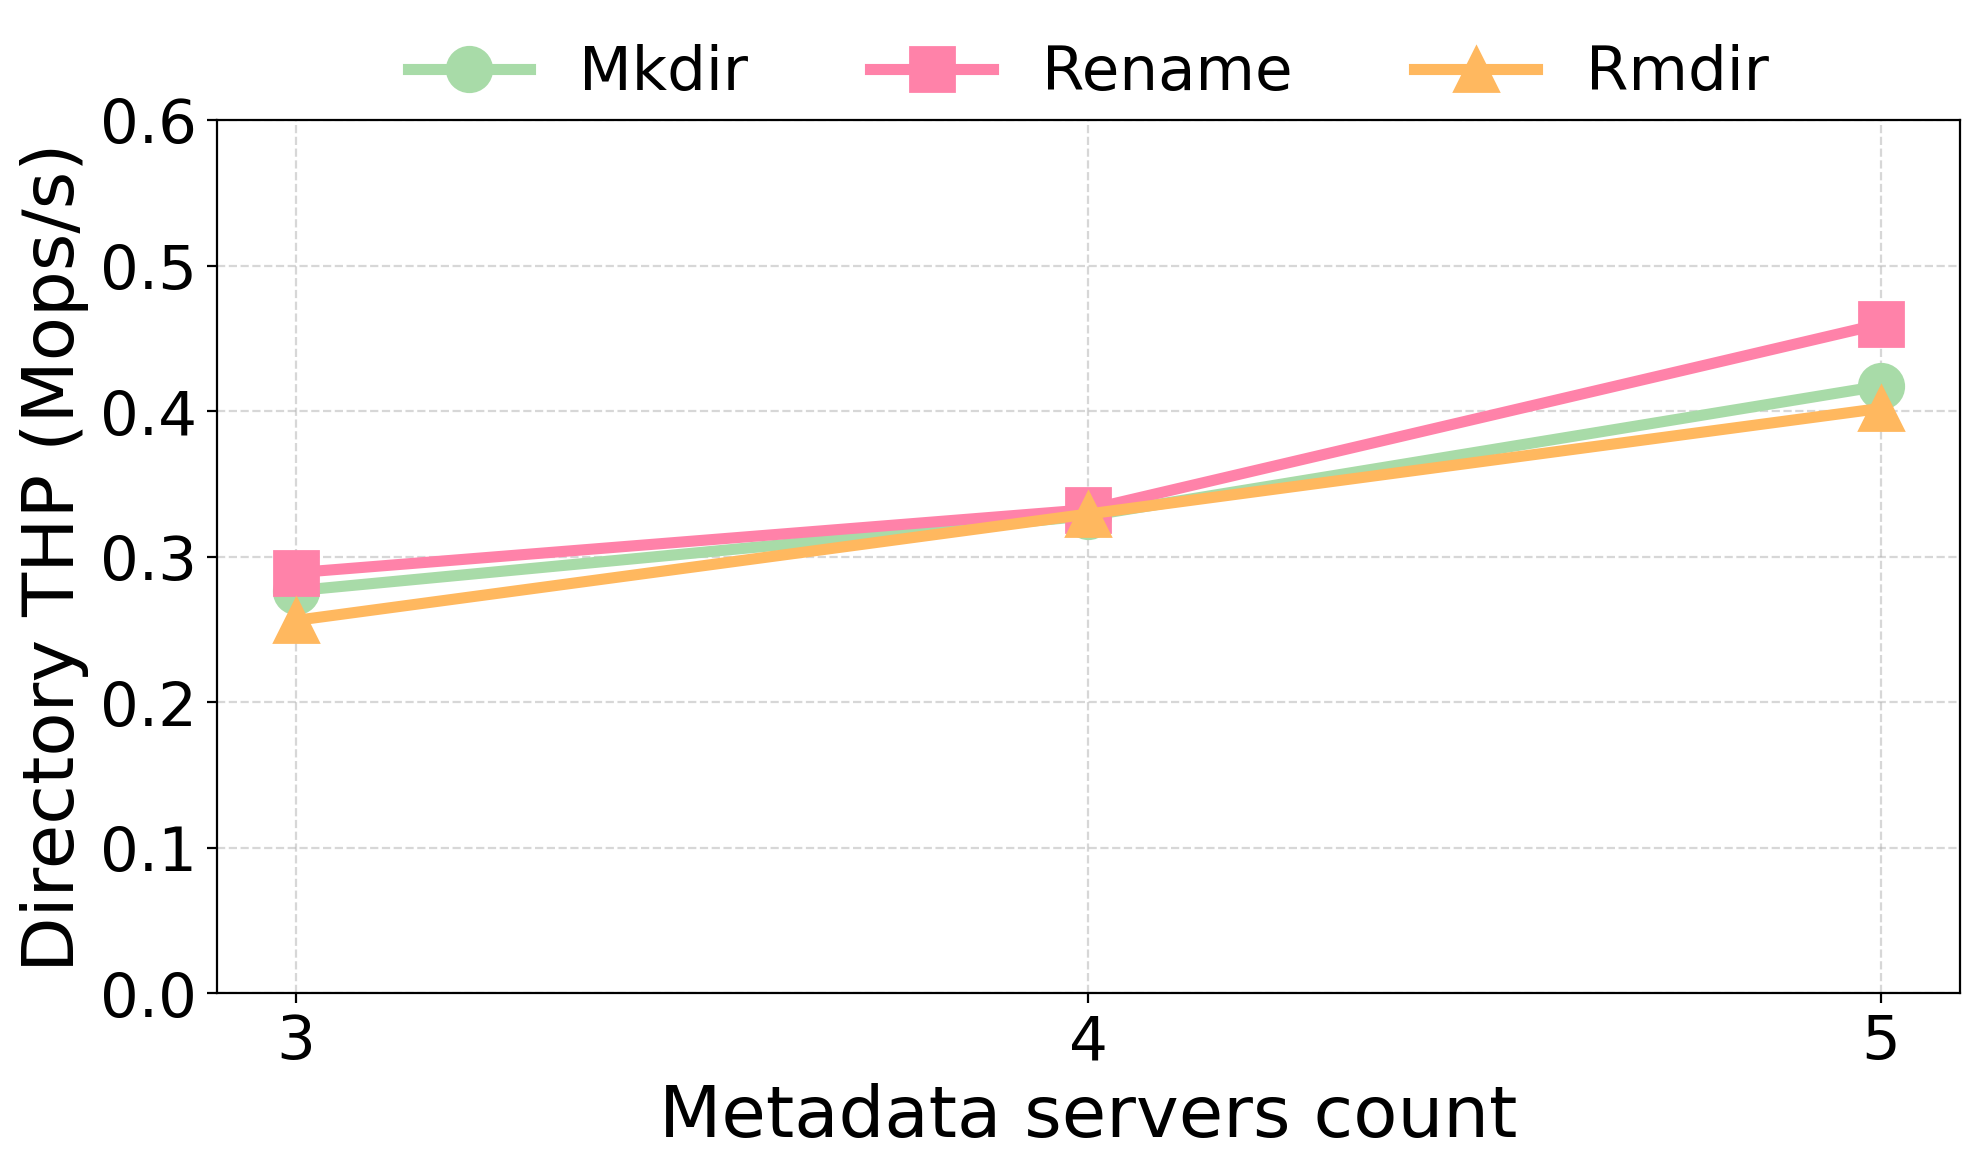

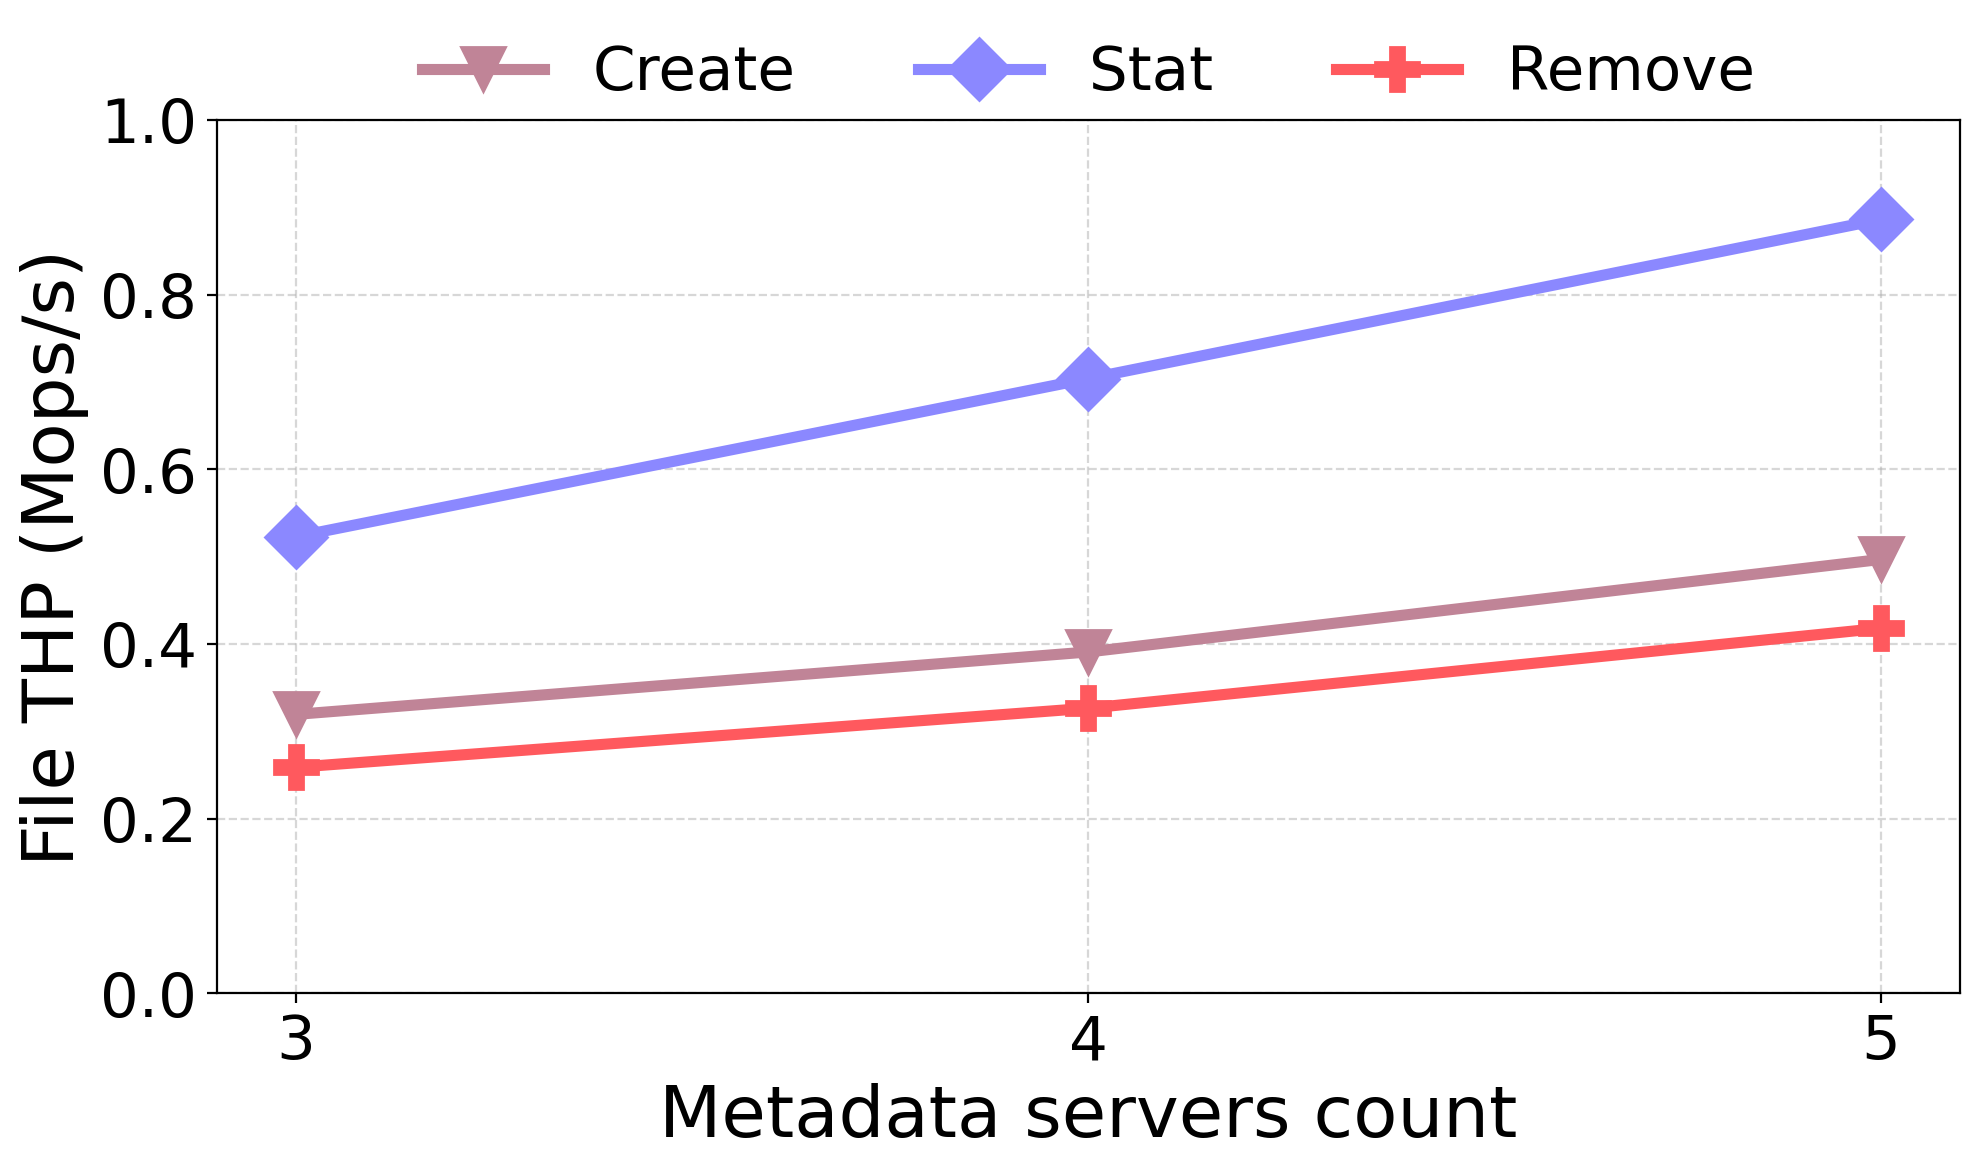

In [10]:
import matplotlib.pyplot as plt

data3 = read_file("../mdtest_5_32_3_4.log")
data4 = read_file("../mdtest_5_64_4_4.log")
data5 = read_file("../mdtest_5_64_5_4.log")
# data6 = read_file("../mdtest_5_64_6_4.log")

datasets = [data3, data4, data5]
x_values = [3, 4, 5]
x_pos = range(len(x_values)) 

operations = ['Directory creation', 'Directory rename', 'Directory removal']
labels = ['Mkdir', 'Rename', 'Rmdir']

operations2 = ['File creation', 'File stat', 'File removal']
labels2 = ['Create', 'Stat', 'Remove']

colors = ['#a8dba8', '#FF82A9', '#FFB85F', '#C08497', '#8B88FF', '#ff595e']
markers = ['o', 's', '^', 'v', 'D', 'P']

plt.figure(figsize=(10, 6), dpi=200)

handles1 = []

for i in range(len(operations)):
    y_values = [d[operations[i]] / 1_000_000 for d in datasets]

    h, = plt.plot(
        x_pos, y_values,
        marker=markers[i],
        label=labels[i],
        markersize=16,
        linewidth=4,
        color=colors[i]
    )
    handles1.append(h)

plt.xticks(x_pos, x_values, fontsize=22)
plt.yticks(fontsize=22)
plt.ylim(0, 0.6)
plt.xlabel("Metadata servers count", fontsize=26)
plt.ylabel("Directory THP (Mops/s)", fontsize=26)
plt.grid(linestyle="--", alpha=0.5)

plt.legend(
    handles1, labels,
    ncol=3,
    fontsize=22,
    loc='upper center',
    bbox_to_anchor=(0.5,1.15),
    frameon=False,
    # handletextpad=0.2,   # marker 和文字之间
    # columnspacing=0.8
)

# plt.legend(handles1, labels, loc='upper left', fontsize=24)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6), dpi=200)

handles2 = []

for i in range(len(operations2)):
    y_values = [d[operations2[i]] / 1_000_000 for d in datasets]

    h, = plt.plot(
        x_pos, y_values,
        marker=markers[i+3],
        label=labels2[i],
        markersize=16,
        linewidth=4,
        color=colors[i + 3]
    )
    handles2.append(h)

plt.xticks(x_pos, x_values, fontsize=22)
plt.yticks(fontsize=22)
plt.xlabel("Metadata servers count", fontsize=26)
plt.ylabel("File THP (Mops/s)", fontsize=26)
plt.ylim(0, 1)
plt.grid(linestyle="--", alpha=0.5)

plt.legend(
    handles2, labels2,
    ncol=3,
    fontsize=22,
    loc='upper center',
    bbox_to_anchor=(0.5,1.15),
    frameon=False,
    # handletextpad=0.2,   # marker 和文字之间
    # columnspacing=0.8
)

# plt.legend(handles2, labels2, loc='upper left', fontsize=24)

plt.tight_layout()
plt.show()


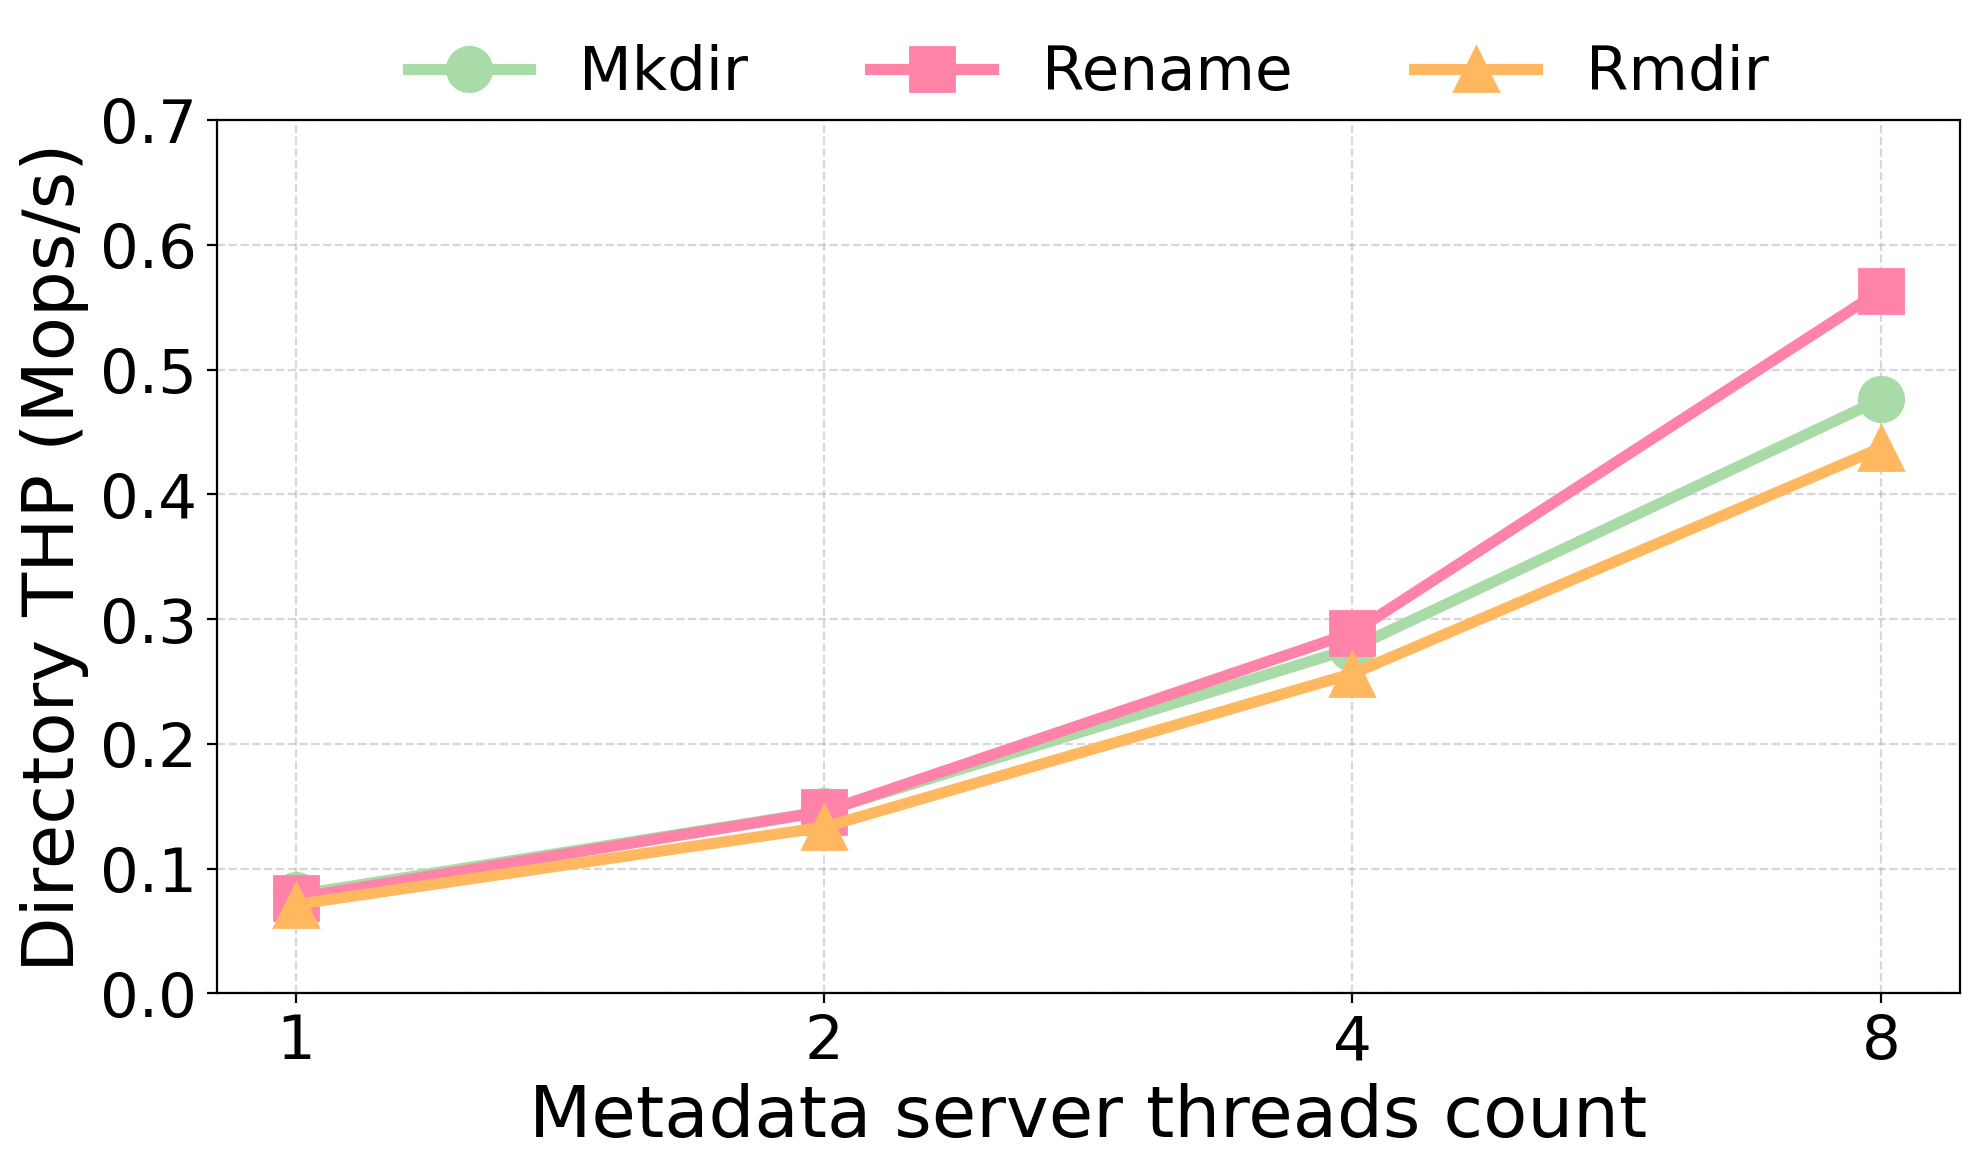

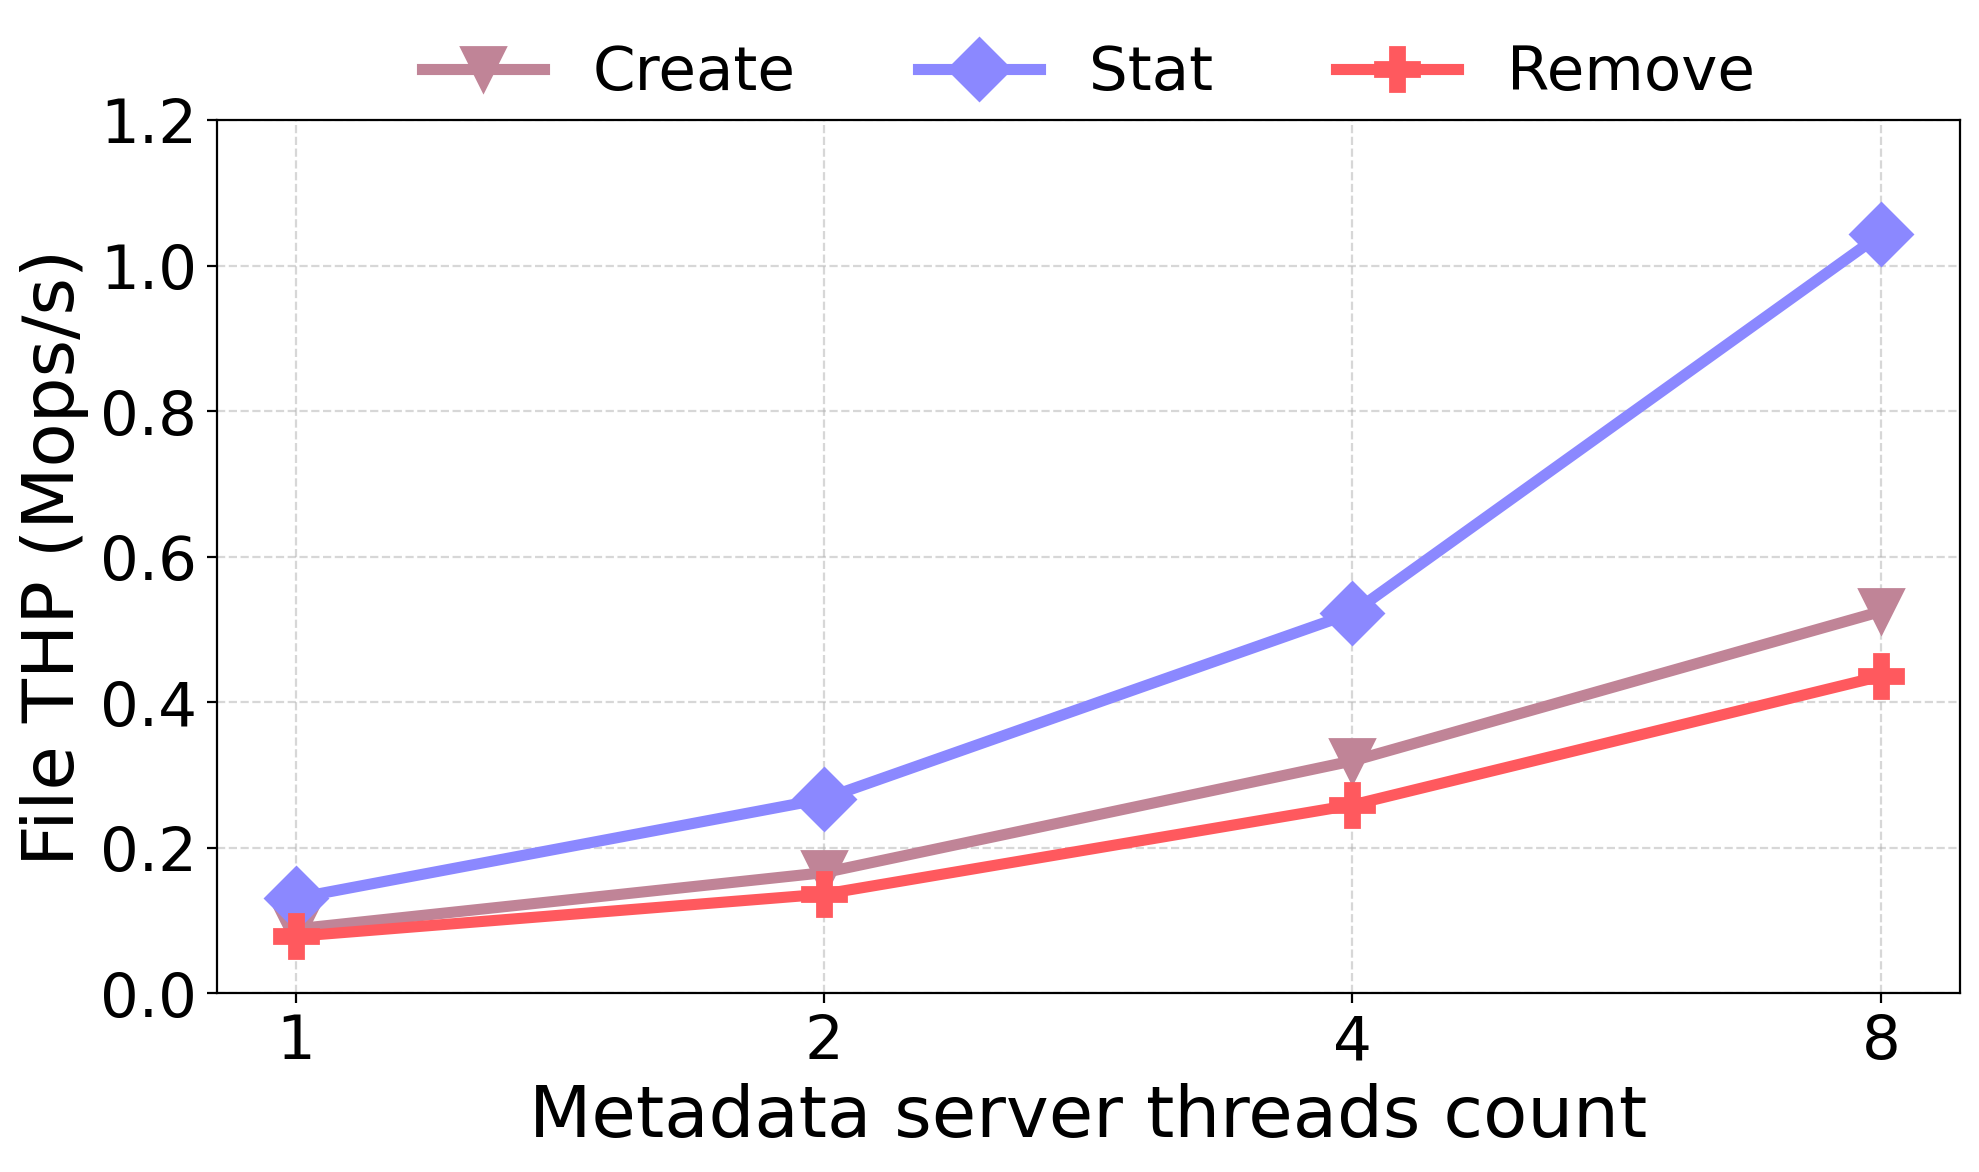

In [84]:
import matplotlib.pyplot as plt

data1 = read_file("../mdtest_5_16_3_1.log")
data2 = read_file("../mdtest_5_16_3_2.log")
data4 = read_file("../mdtest_5_32_3_4.log")
data8 = read_file("../mdtest_5_64_3_8.log")

datasets = [data1, data2, data4, data8]
x_values = [1, 2, 4, 8]
x_pos = range(len(x_values)) 

operations = ['Directory creation', 'Directory rename', 'Directory removal']
labels = ['Mkdir', 'Rename', 'Rmdir']

operations2 = ['File creation', 'File stat', 'File removal']
labels2 = ['Create', 'Stat', 'Remove']

colors = ['#a8dba8', '#FF82A9', '#FFB85F', '#C08497', '#8B88FF', '#ff595e']
markers = ['o', 's', '^', 'v', 'D', 'P']

plt.figure(figsize=(10, 6), dpi=200)

handles1 = []

for i in range(len(operations)):
    y_values = [d[operations[i]] / 1_000_000 for d in datasets]

    h, = plt.plot(
        x_pos, y_values,
        marker=markers[i],
        label=labels[i],
        markersize=16,
        linewidth=4,
        color=colors[i]
    )
    handles1.append(h)

plt.xticks(x_pos, x_values, fontsize=22)
plt.yticks(fontsize=22)
plt.xlabel("Metadata server threads count", fontsize=26)
plt.ylabel("Directory THP (Mops/s)", fontsize=26)
plt.ylim(0, 0.7)
plt.grid(linestyle="--", alpha=0.5)

plt.legend(
    handles1, labels,
    ncol=3,
    fontsize=22,
    loc='upper center',
    bbox_to_anchor=(0.5,1.15),
    frameon=False,
    # handletextpad=0.2,   # marker 和文字之间
    # columnspacing=0.8
)

# plt.legend(handles1, labels, loc='upper left', fontsize=24)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6), dpi=200)

handles2 = []

for i in range(len(operations2)):
    y_values = [d[operations2[i]] / 1_000_000 for d in datasets]

    h, = plt.plot(
        x_pos, y_values,
        marker=markers[i+3],
        label=labels2[i],
        markersize=16,
        linewidth=4,
        color=colors[i + 3]
    )
    handles2.append(h)

plt.xticks(x_pos, x_values, fontsize=22)
plt.yticks(fontsize=22)
plt.xlabel("Metadata server threads count", fontsize=26)
plt.ylabel("File THP (Mops/s)", fontsize=26)
plt.ylim(0, 1.2)
plt.grid(linestyle="--", alpha=0.5)

plt.legend(
    handles2, labels2,
    ncol=3,
    fontsize=22,
    loc='upper center',
    bbox_to_anchor=(0.5,1.15),
    frameon=False,
    # handletextpad=0.2,   # marker 和文字之间
    # columnspacing=0.8
)

# plt.legend(handles2, labels2, loc='upper left', fontsize=24)

plt.tight_layout()
plt.show()


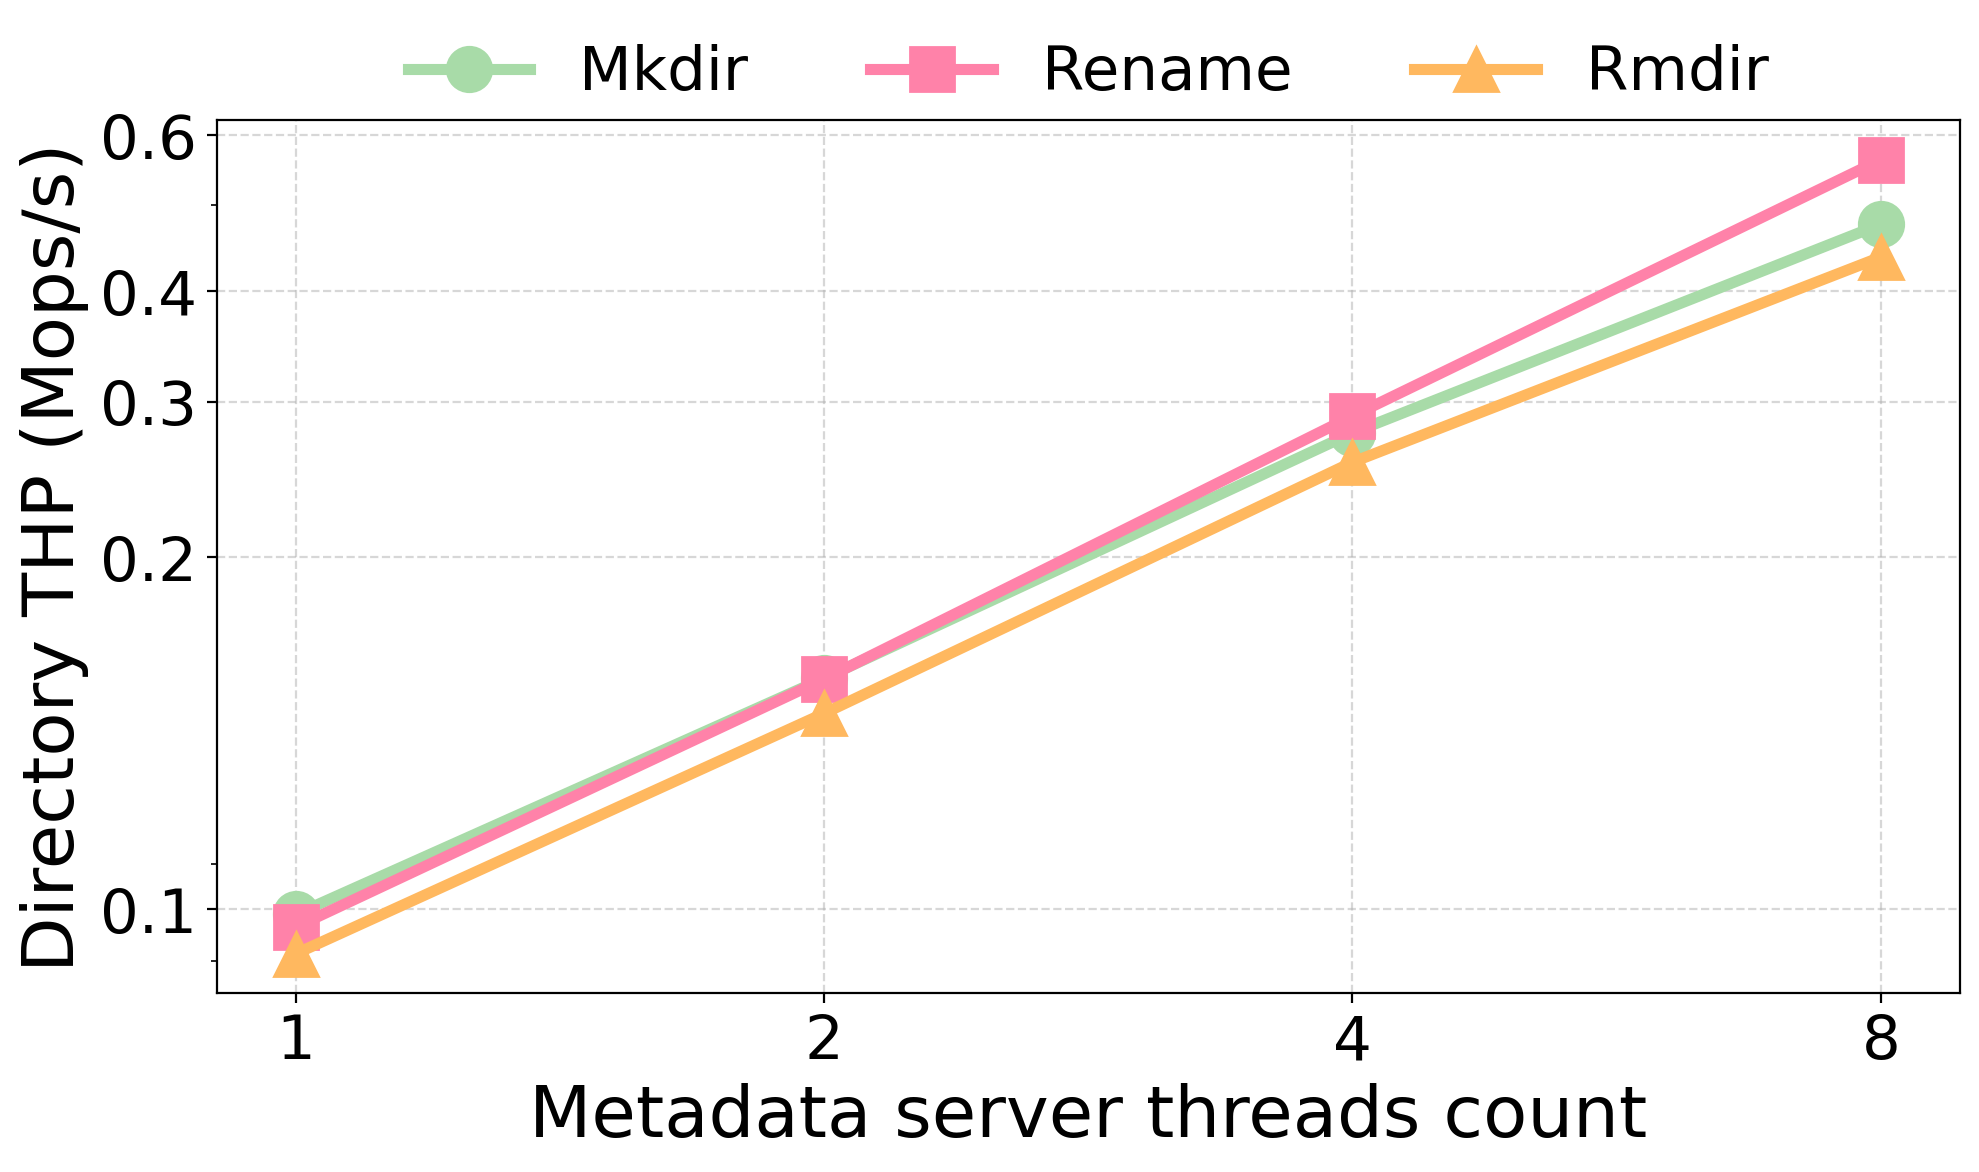

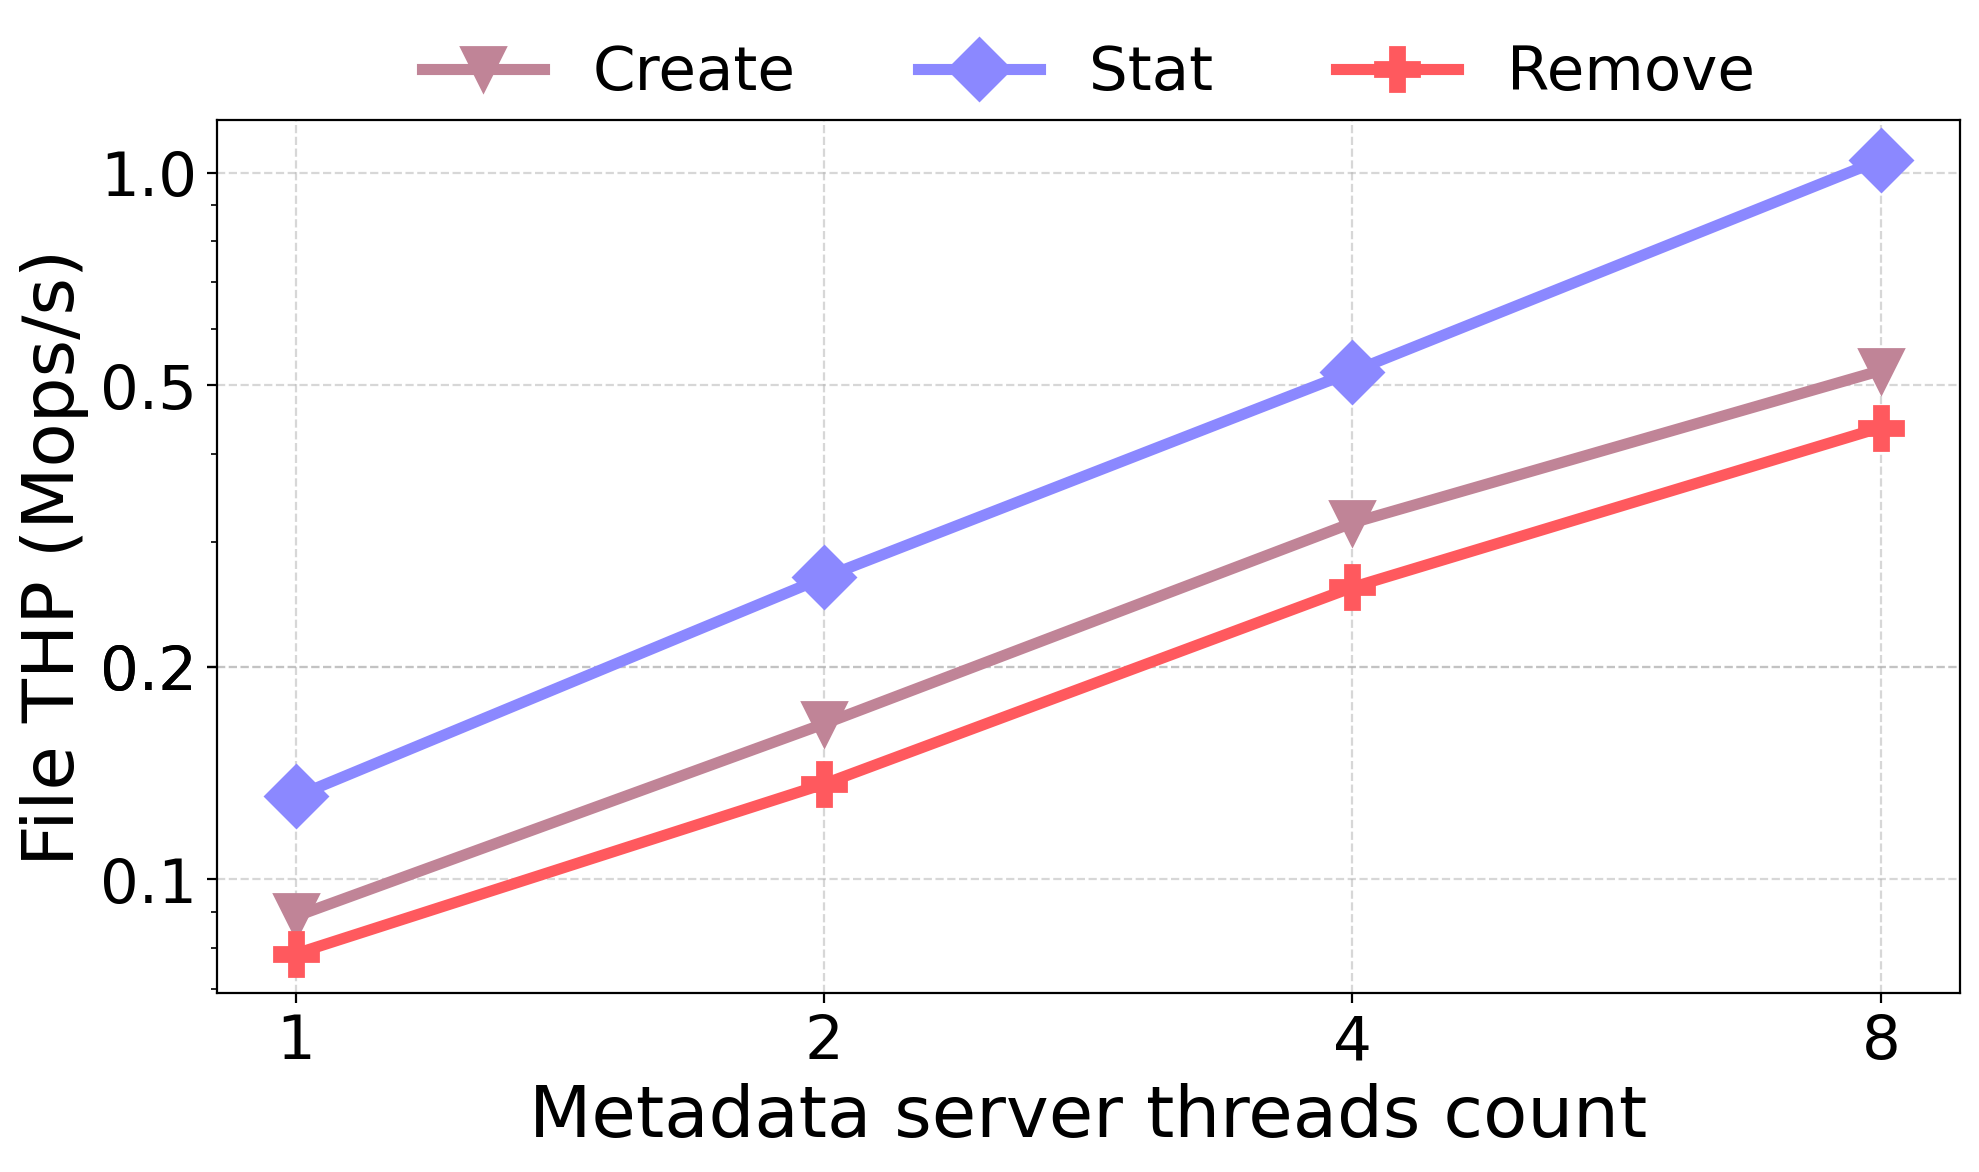

In [85]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, LogLocator

data1 = read_file("../mdtest_5_16_3_1.log")
data2 = read_file("../mdtest_5_16_3_2.log")
data4 = read_file("../mdtest_5_32_3_4.log")
data8 = read_file("../mdtest_5_64_3_8.log")

datasets = [data1, data2, data4, data8]
x_values = [1, 2, 4, 8]
x_pos = range(len(x_values)) 

operations = ['Directory creation', 'Directory rename', 'Directory removal']
labels = ['Mkdir', 'Rename', 'Rmdir']

operations2 = ['File creation', 'File stat', 'File removal']
labels2 = ['Create', 'Stat', 'Remove']

colors = ['#a8dba8', '#FF82A9', '#FFB85F', '#C08497', '#8B88FF', '#ff595e']
markers = ['o', 's', '^', 'v', 'D', 'P']

plt.figure(figsize=(10, 6), dpi=200)

handles1 = []

for i in range(len(operations)):
    y_values = [d[operations[i]] / 1_000_000 for d in datasets]

    h, = plt.plot(
        x_pos, y_values,
        marker=markers[i],
        label=labels[i],
        markersize=16,
        linewidth=4,
        color=colors[i]
    )
    handles1.append(h)

plt.xticks(x_pos, x_values, fontsize=22)
plt.yticks(fontsize=22)
plt.xlabel("Metadata server threads count", fontsize=26)
plt.ylabel("Directory THP (Mops/s)", fontsize=26)
ax = plt.gca()
ax.set_yscale('log')
ax.yaxis.set_major_locator(LogLocator(base=10, subs=[2,3,4,6,8]))
ax.yaxis.set_major_formatter(FuncFormatter(lambda x,_: f"{x:.1f}"))

plt.grid(linestyle="--", alpha=0.5)

plt.legend(
    handles1, labels,
    ncol=3,
    fontsize=22,
    loc='upper center',
    bbox_to_anchor=(0.5,1.15),
    frameon=False,
    # handletextpad=0.2,   # marker 和文字之间
    # columnspacing=0.8
)

# plt.legend(handles1, labels, loc='upper left', fontsize=24)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6), dpi=200)

handles2 = []

for i in range(len(operations2)):
    y_values = [d[operations2[i]] / 1_000_000 for d in datasets]

    h, = plt.plot(
        x_pos, y_values,
        marker=markers[i+3],
        label=labels2[i],
        markersize=16,
        linewidth=4,
        color=colors[i + 3]
    )
    handles2.append(h)

plt.xticks(x_pos, x_values, fontsize=22)
plt.yticks(fontsize=22)
plt.xlabel("Metadata server threads count", fontsize=26)
plt.ylabel("File THP (Mops/s)", fontsize=26)
ax2 = plt.gca()
ax2.set_yscale('log')
ax2.yaxis.set_major_locator(LogLocator(base=10, subs=[2,5,10,20]))
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x,_: f"{x:.1f}"))
plt.grid(linestyle="--", alpha=0.5)

plt.legend(
    handles2, labels2,
    ncol=3,
    fontsize=22,
    loc='upper center',
    bbox_to_anchor=(0.5,1.15),
    frameon=False,
)

plt.tight_layout()
plt.show()


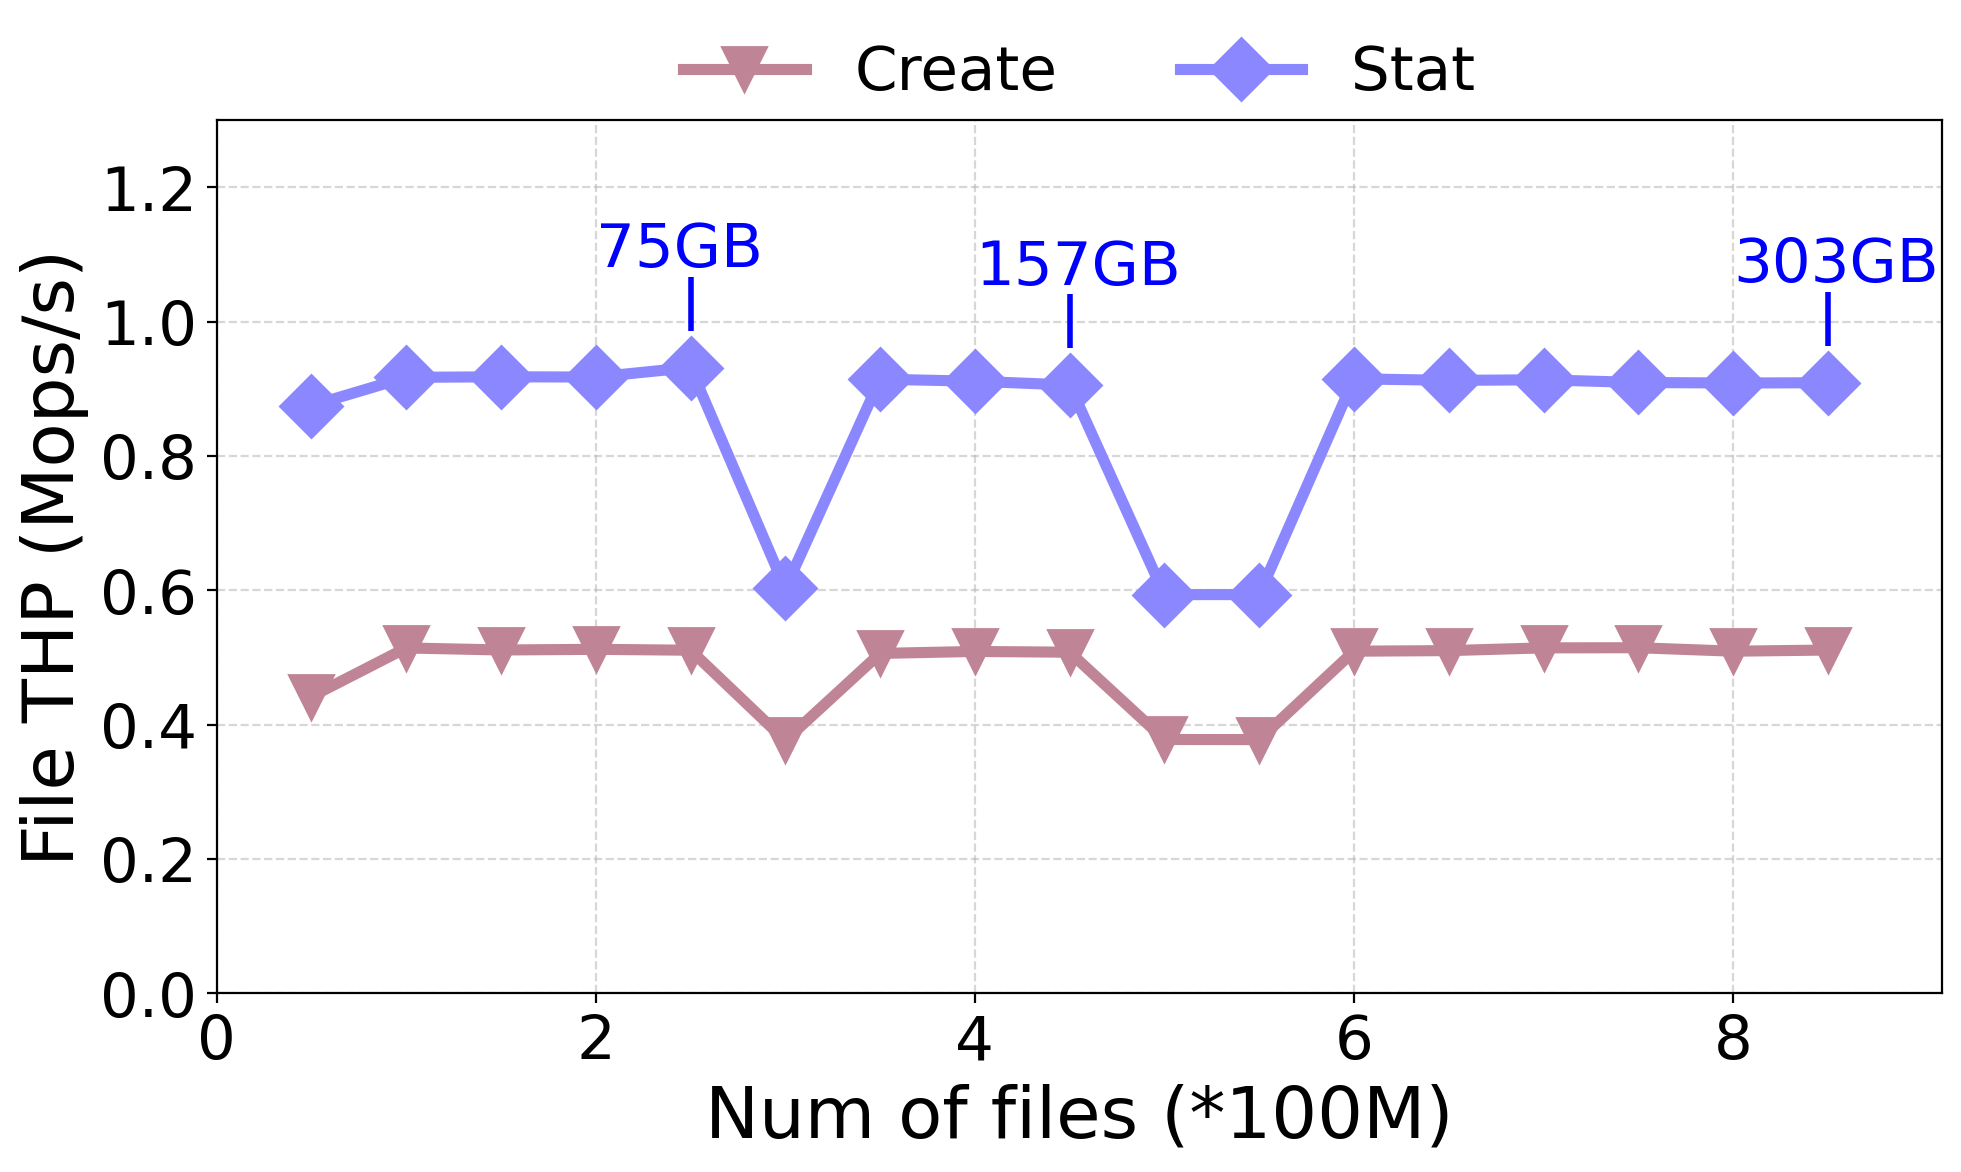

In [ ]:
import matplotlib.pyplot as plt

data1 = read_file("../mdtest_round_1.log")
data2 = read_file("../mdtest_round_5.log")
data3 = read_file("../mdtest_round_10.log")
data4 = read_file("../mdtest_round_15.log")
data5 = read_file("../mdtest_round_20.log")
data6 = read_file("../mdtest_round_25.log")
data7 = read_file("../mdtest_round_30.log")
data8 = read_file("../mdtest_round_35.log")
data9 = read_file("../mdtest_round_40.log")
data10 = read_file("../mdtest_round_45.log")
data11 = read_file("../mdtest_round_50.log")
data12 = read_file("../mdtest_round_55.log")
data13 = read_file("../mdtest_round_60.log")
data14 = read_file("../mdtest_round_65.log")
data15 = read_file("../mdtest_round_70.log")
data16 = read_file("../mdtest_round_75.log")
data17 = read_file("../mdtest_round_80.log")

datasets = [data1, data2, data3, data4, data5, data6, data7, data8, data9, data10, data11, data12, data13, data14, data15, data16, data17]
x_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
x_values = [x / 2 for x in x_values]

operations = ['File creation', 'File stat']
labels = ['Create', 'Stat']

colors = ['#C08497', '#8B88FF']
markers = ['v', 'D', 'P']

plt.figure(figsize=(10, 6), dpi=200)

handles1 = []

for i in range(len(operations)):
    y_values = [d[operations[i]] / 1_000_000 for d in datasets]

    h, = plt.plot(
        x_values, y_values,
        marker=markers[i],
        label=labels[i],
        markersize=16,
        linewidth=4,
        color=colors[i]
    )
    handles1.append(h)

plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.xlabel("Num of files (*100M)", fontsize=26)
plt.ylabel("File THP (Mops/s)", fontsize=26)
plt.ylim(0, 1.3)
plt.xlim(0, 9.1)
plt.grid(linestyle="--", alpha=0.5)

plt.legend(
    handles1, labels,
    ncol=3,
    fontsize=22,
    loc='upper center',
    bbox_to_anchor=(0.5,1.15),
    frameon=False,
    # handletextpad=0.2,   # marker 和文字之间
    # columnspacing=0.8
)

# ========= 添加文字标注 =========
create_y = [d['File stat'] / 1_000_000 for d in datasets]

plt.text(2, create_y[4] + 0.15, "75GB", fontsize=22, color='blue')
plt.text(4, create_y[8] + 0.15, "157GB", fontsize=22, color='blue')
plt.text(8, create_y[16] + 0.15, "303GB", fontsize=22, color='blue')

# ========= 添加竖线 =========
plt.vlines(2.5, ymin=create_y[4]+0.055, ymax=create_y[4]+0.135, color='blue', linewidth=2)
plt.vlines(4.5, ymin=create_y[8]+0.055, ymax=create_y[8]+0.135, color='blue', linewidth=2)
plt.vlines(8.5, ymin=create_y[16]+0.055, ymax=create_y[16]+0.135, color='blue', linewidth=2)

plt.tight_layout()
plt.show()


In [35]:
print(max([d[operations[0]] / 1_000_000 for d in datasets]))
print(min([d[operations[0]] / 1_000_000 for d in datasets]))

print(max([d[operations[1]] / 1_000_000 for d in datasets]))
print(min([d[operations[1]] / 1_000_000 for d in datasets]))

0.514582427
0.376538362
0.9316600309999999
0.593653059


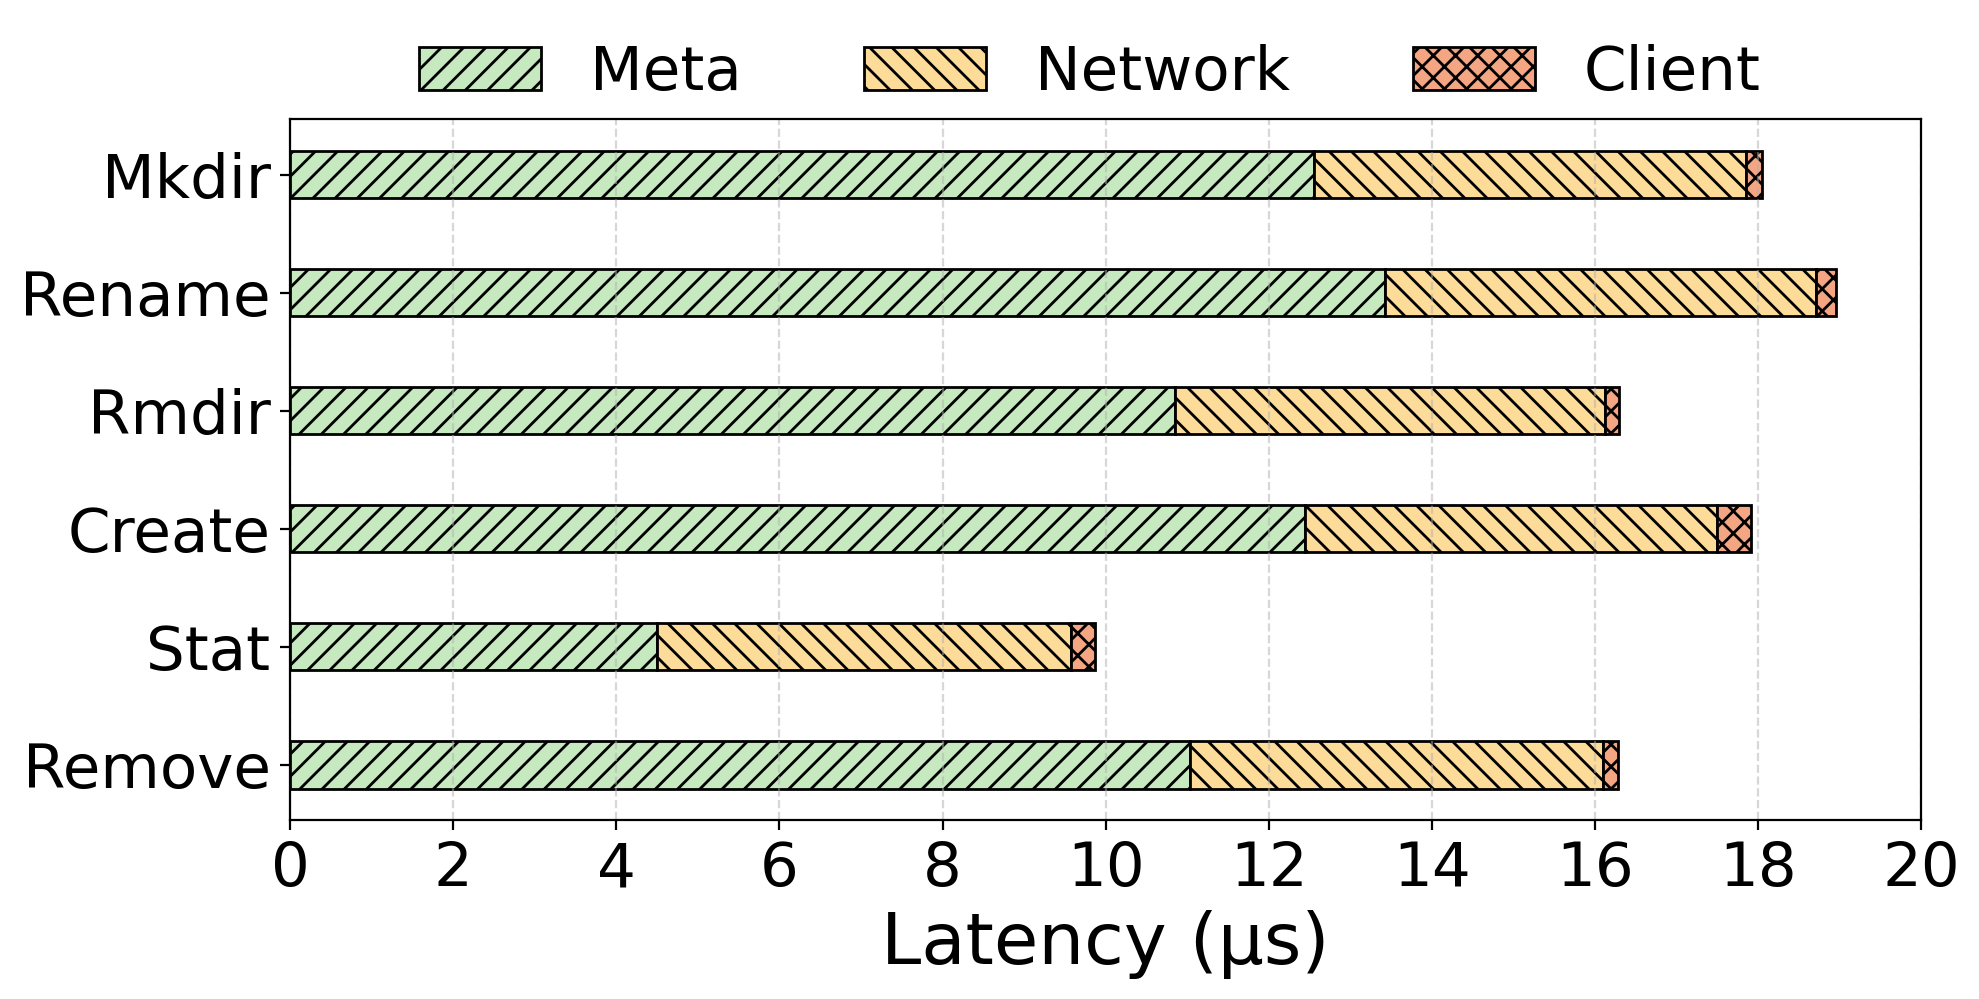

In [41]:
import matplotlib.pyplot as plt
import numpy as np

data1 = read_file("../mdtest_latency_hook_return.log")     # client
data2 = read_file("../mdtest_latency_mds_return.log")      # network + client
data3 = read_file("../mdtest_latency_normal.log")          # meta + network + client

operations = ['Directory creation', 'Directory rename', 'Directory removal', 'File creation', 'File stat', 'File removal']

labels = ['Mkdir', 'Rename', 'Rmdir', 'Create', 'Stat', 'Remove']

meta_color = "#c7e9c0"
network_color = "#fddc9a"
client_color = "#f4a582"

fig, ax = plt.subplots(figsize=(10, 5), dpi=200)

y_pos = np.arange(len(operations))
y_pos = y_pos[::-1]

meta_vals = []
network_vals = []
client_vals = []

for op in operations:
    client = 1 / data1[op] * 1_000_000
    network = (1 / data2[op] - 1 / data1[op]) * 1_000_000
    meta = (1 / data3[op] - 1 / data2[op]) * 1_000_000

    client_vals.append(client)
    network_vals.append(network)
    meta_vals.append(meta)

bar_height = 0.4

h_meta = ax.barh(
    y_pos, meta_vals,
    height=bar_height,
    color=meta_color, edgecolor='black',
    hatch='///',
    label="Meta"
)

h_network = ax.barh(
    y_pos, network_vals,
    height=bar_height,
    left=meta_vals,
    color=network_color, edgecolor='black',
    hatch='\\\\\\',
    label="Network"
)

h_client = ax.barh(
    y_pos, client_vals,
    height=bar_height,
    left=np.array(meta_vals) + np.array(network_vals),
    color=client_color, edgecolor='black',
    hatch='xxx',
    label="Client"
)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=22)
ax.set_xticks(range(0, 21, 2))
ax.tick_params(labelsize=22)
ax.set_xlabel("Latency (µs)", fontsize=26)
ax.grid(axis='x', linestyle='--', alpha=0.5)

fig.legend(
    [h_meta, h_network, h_client],
    ["Meta", "Network", "Client"],
    loc="upper center",
    ncol=3,
    fontsize=22,
    frameon=False,
    bbox_to_anchor=(0.55, 1.02)
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


In [45]:
print(meta_vals, mean(meta_vals))
print(network_vals, mean(network_vals))
print(client_vals, mean(client_vals))
print([meta + network + client for meta, network, client in zip(meta_vals, network_vals, client_vals)], mean([meta + network + client for meta, network, client in zip(meta_vals, network_vals, client_vals)]))

[12.559850148317658, 13.423865489753426, 10.852757238818372, 12.449145408091654, 4.502622129305469, 11.035568916810005] 10.80396822184943
[5.291965574237788, 5.2852970077097865, 5.267833383154219, 5.045915443823443, 5.068082904546305, 5.060714420058899] 5.1699681222550735
[0.19028411012031518, 0.2413275280979656, 0.17102884515720845, 0.41946190170541375, 0.30198270863377824, 0.18855198183827038] 0.2521061792588253
[18.042099832675763, 18.950490025561177, 16.2916194671298, 17.914522753620513, 9.872687742485551, 16.284835318707174] 16.22604252336333


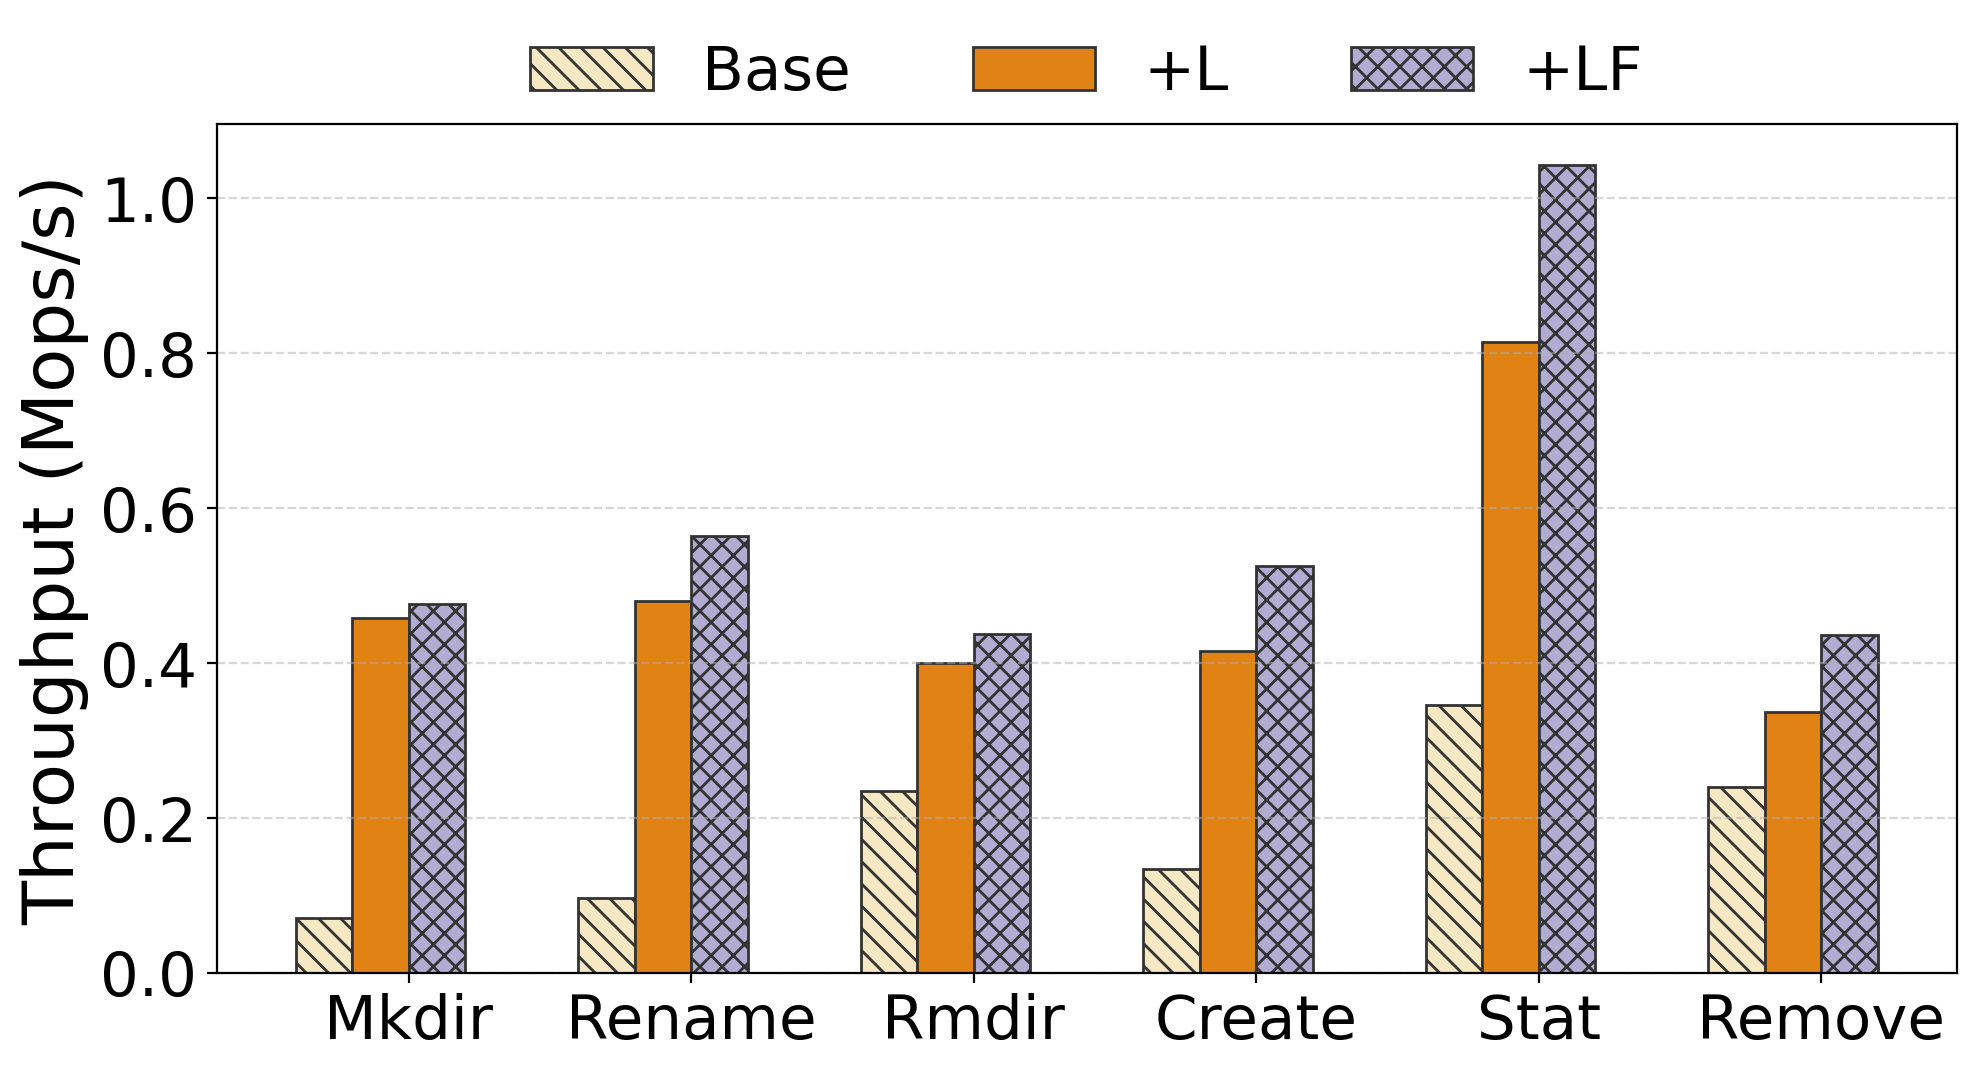

In [118]:
import matplotlib.pyplot as plt
import numpy as np

# 读取数据
data1 = read_file("../base_mdtest_5_64_3_8.log")        # base
data2 = read_file("../mdtest_5_64_nohint_3_8.log")     # +Layout
data3 = read_file("../mdtest_5_64_3_8.log")             # +Layout +Filter

datasets = [data1, data2, data3]
configs = ["Base", "+L", "+LF"]

operations = [
    'Directory creation', 'Directory rename', 'Directory removal',
    'File creation', 'File stat', 'File removal'
]
labels = ['Mkdir', 'Rename', 'Rmdir', 'Create', 'Stat', 'Remove']

# 颜色与示例图风格
# colors = ["#f6d565", "#d6e9a7", "#9cd3b3", "#7aa5d8"]
colors = [
    "#f6e8c3", "#e08214",
    "#b2abd2", "#8073ac"
]

hatches = ["\\\\\\", "", "xxx"]

num_ops = len(operations)
num_cfg = len(datasets)

x = np.arange(num_ops)   # 6 个横坐标
bar_width = 0.2         # 每个柱子宽度

plt.figure(figsize=(10, 6), dpi=200)

# ======= 绘制多个配置的柱状图 =======
for cfg_idx in range(num_cfg):
    values = [datasets[cfg_idx][op] / 1_000_000 for op in operations]

    plt.bar(
        x + cfg_idx * bar_width,
        values,
        width=bar_width,
        label=configs[cfg_idx],
        color=colors[cfg_idx],
        edgecolor='0.2',
        hatch=hatches[cfg_idx]
    )

# 坐标轴标注
plt.xticks(x + bar_width * 1.5, labels, fontsize=22)
plt.yticks(fontsize=22)
plt.ylabel("Throughput (Mops/s)", fontsize=26)

# 图例放上方
plt.legend(ncol=4, fontsize=22, loc="upper center", 
           bbox_to_anchor=(0.5, 1.16), frameon=False)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


In [ ]:
print(data1)
print(data2)
print(data3)

{'Directory creation': 373068.349, 'Directory stat': 503736.947, 'Directory rename': 444330.613, 'Directory removal': 477338.979, 'File creation': 400354.071, 'File stat': 547389.811, 'File read': 0.0, 'File removal': 506574.895, 'Tree creation': 4489.59, 'Tree removal': 753.505}
{'Directory creation': 814368.481, 'Directory stat': 1408836.936, 'Directory rename': 602683.567, 'Directory removal': 807130.208, 'File creation': 721325.799, 'File stat': 1957556.683, 'File read': 0.0, 'File removal': 988826.852, 'Tree creation': 5342.406, 'Tree removal': 3148.327}
[2.1828876673543074, 2.796765549211245, 1.3563823715599548, 1.6908916988074028, 1.8017151554950581, 3.576159196797332, 0.0, 1.9519816512390507, 1.1896891054404877, 4.172705283596531]
{'Directory creation': 894216.034, 'Directory stat': 1268956.239, 'Directory rename': 507572.689, 'Directory removal': 622886.595, 'File creation': 737893.519, 'File stat': 2244308.525, 'File read': 0.0, 'File removal': 635014.442, 'Tree creation': 55

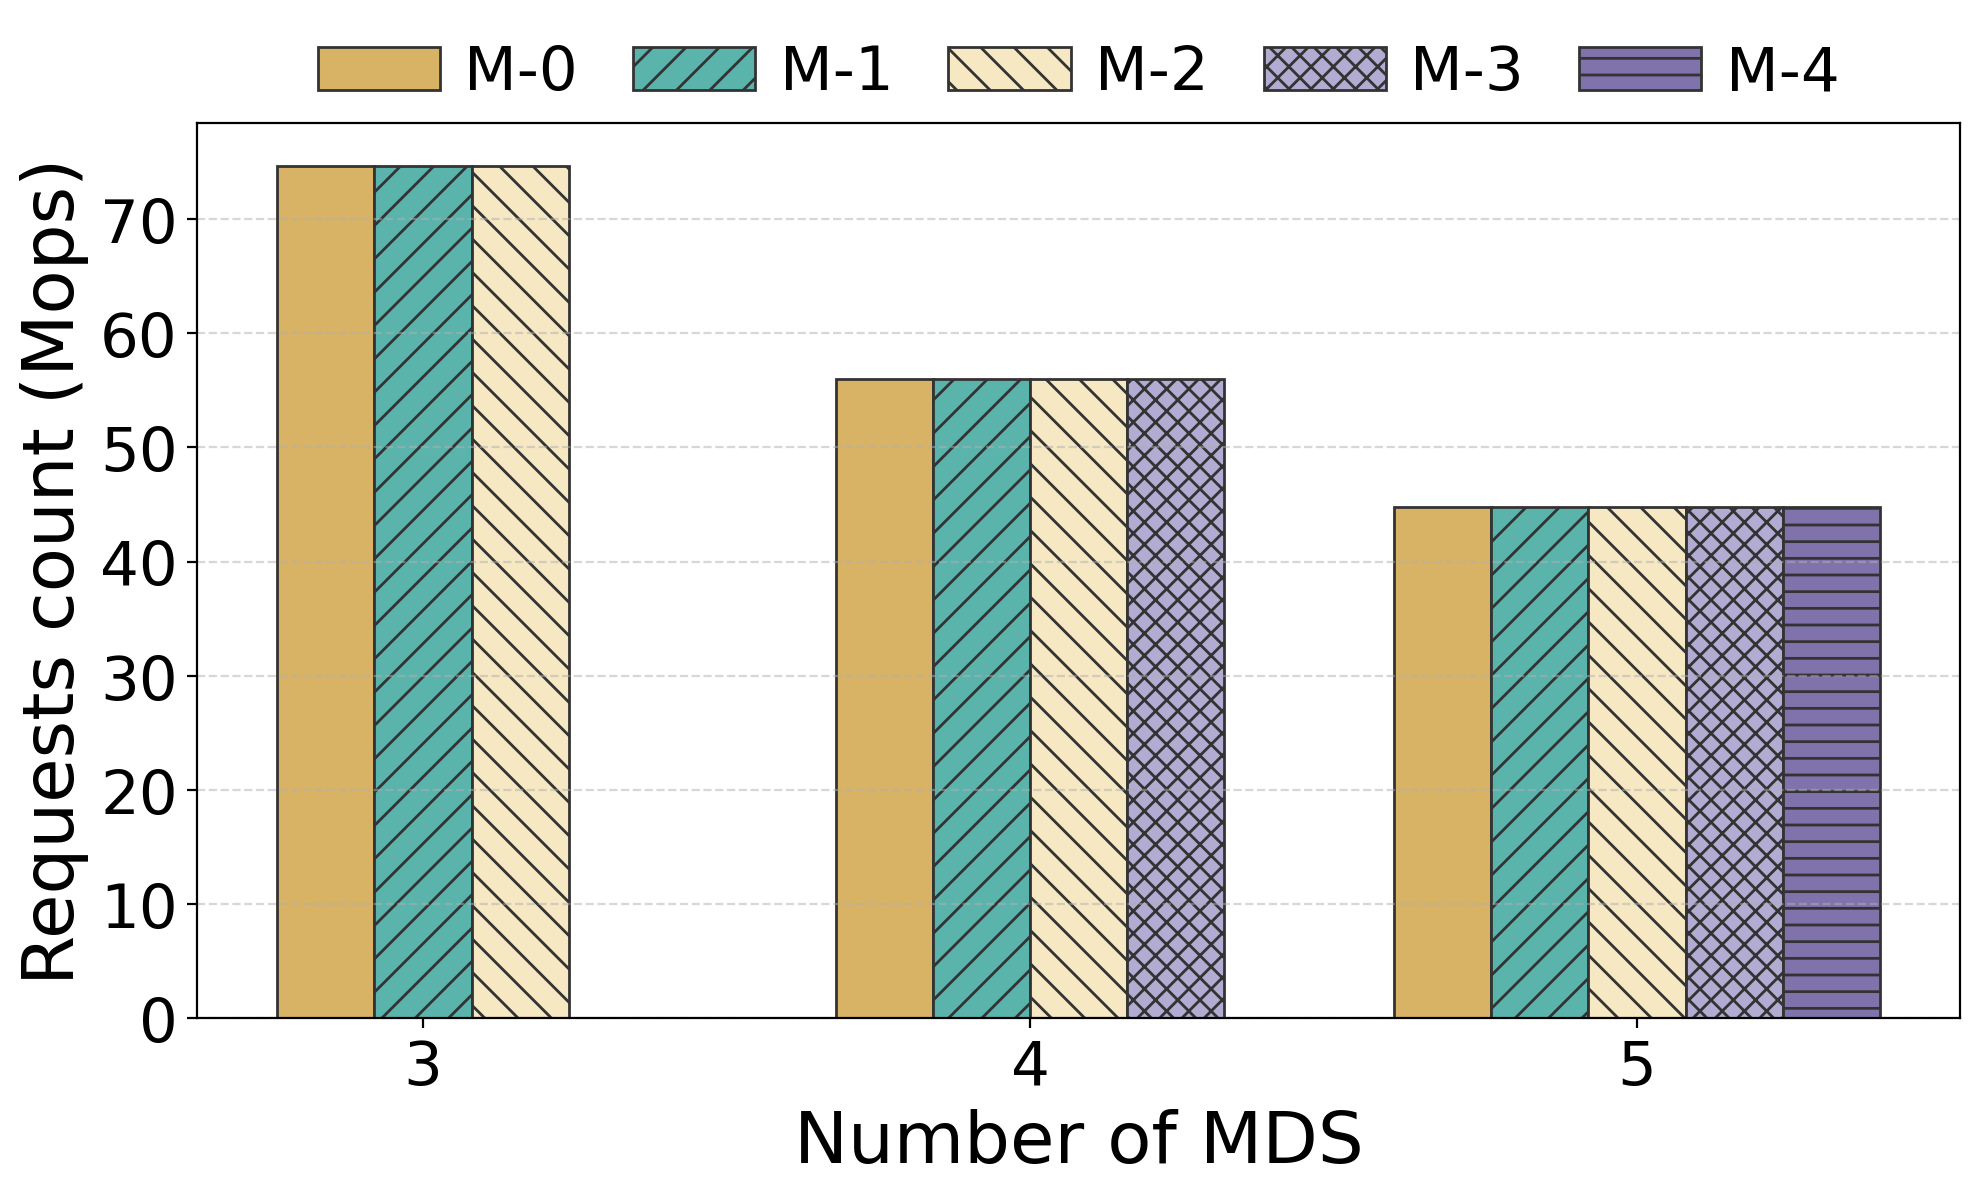

In [60]:
import numpy as np
import matplotlib.pyplot as plt

# mdtest, 5*64 client, 3/4/5/6 meta requests count
reqs_3_4 = [np.float64(74.666118), np.float64(74.66691800000001), np.float64(74.667704)]
reqs_4_4 = [np.float64(55.999072000000005), np.float64(55.99610000000001), np.float64(56.005236), np.float64(55.999168000000004)]
reqs_5_4 = [np.float64(44.78621), np.float64(44.807430000000004), np.float64(44.795092), np.float64(44.79681), np.float64(44.812154)]

groups = {
    3: reqs_3_4,
    4: reqs_4_4,
    5: reqs_5_4,
}

group_labels = sorted(groups.keys())          # [3,4,5,6]
n_groups = len(group_labels)

# 每个组在 x 轴上的中心位置
x_group = np.arange(n_groups)

# 当前所有实验中最大的 mds 数，用来决定柱宽
max_mds = max(len(v) for v in groups.values())
bar_width = 0.8 / max_mds                     # 一组里总宽度控制在 0.8

# 给每个 mds 一个固定颜色
# colors = ["#f6d565", "#d6e9a7", "#9cd3b3", "#7aa5d8", '#ff595e', '#8B88FF']
colors = [
    "#d8b365", "#5ab4ac", "#f6e8c3",
    "#b2abd2", "#8073ac", "#e08214"
]
hatches = ['', '//', '\\\\', 'xxx', '--', '..']

plt.figure(figsize=(10, 6), dpi=200)

for mds_id in range(max_mds):
    xs, ys = [], []
    for gi, mds_num in enumerate(group_labels):
        reqs = groups[mds_num]
        if mds_id >= len(reqs):
            # 这组实验里没有这么多 mds，就跳过
            continue

        # 让这一组的柱子以组中心对称展开
        offset = -(len(reqs) - 1) * bar_width / 2.0
        x = x_group[gi] + offset + mds_id * bar_width

        xs.append(x)
        ys.append(reqs[mds_id])

    if xs:
        plt.bar(xs, ys,
                width=bar_width,
                edgecolor='0.2',
                color=colors[mds_id],
                label=f'MDS-{mds_id}',
                hatch=hatches[mds_id])

plt.xticks(x_group, [f'{k}' for k in group_labels])
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xlabel('Number of MDS', fontsize=26)
plt.ylabel('Requests count (Mops)', fontsize=26)
plt.legend(
    [f"M-{i}" for i in range(max_mds)],
    ncol=6,
    fontsize=22,
    loc='upper center',
    bbox_to_anchor=(0.5,1.15),
    frameon=False,
    handletextpad=0.4,   # marker 和文字之间
    columnspacing=0.9
)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.tight_layout()
plt.show()


In [86]:
data1 = {
 'Directory creation': 48125.805,
 'Directory rename': 48051.852,
 'Directory removal': 36160.471,
 'File creation': 56411.794,
 'File stat': 208821.169,
 'File removal': 36154.301}
data2 = {
 'Directory creation': 83288.865,
 'Directory rename': 82497.844,
 'Directory removal': 72854.348,
 'File creation': 224119.351,
 'File stat': 380766.847,
 'File removal': 208211.888}
data3 = read_file("../base_mdtest_5_64_3_8.log")  
data4 = read_file("../mdtest_5_64_3_8.log")  
operations = [
    'Directory creation', 'Directory rename', 'Directory removal',
    'File creation', 'File stat', 'File removal'
]
for op in operations:
    val1 = data1[op] / 1000
    val2 = data2[op] / 1000
    val3 = data3[op] / 1000
    val4 = data4[op] / 1000
    speedup_1 = val4 / val1
    speedup_2 = val4 / val2
    speedup_3 = val4 / val3
    print(f"{op}: {val1:.2f} -> {val4:.2f} ({speedup_1:.2f}x), {val2:.2f} -> {val4:.2f} ({speedup_2:.2f}x), {val3:.2f} -> {val4:.2f} ({speedup_3:.2f}x)")

Directory creation: 48.13 -> 476.12 (9.89x), 83.29 -> 476.12 (5.72x), 70.59 -> 476.12 (6.75x)
Directory rename: 48.05 -> 563.23 (11.72x), 82.50 -> 563.23 (6.83x), 96.65 -> 563.23 (5.83x)
Directory removal: 36.16 -> 437.13 (12.09x), 72.85 -> 437.13 (6.00x), 234.89 -> 437.13 (1.86x)
File creation: 56.41 -> 524.80 (9.30x), 224.12 -> 524.80 (2.34x), 133.48 -> 524.80 (3.93x)
File stat: 208.82 -> 1042.83 (4.99x), 380.77 -> 1042.83 (2.74x), 345.43 -> 1042.83 (3.02x)
File removal: 36.15 -> 435.88 (12.06x), 208.21 -> 435.88 (2.09x), 239.36 -> 435.88 (1.82x)


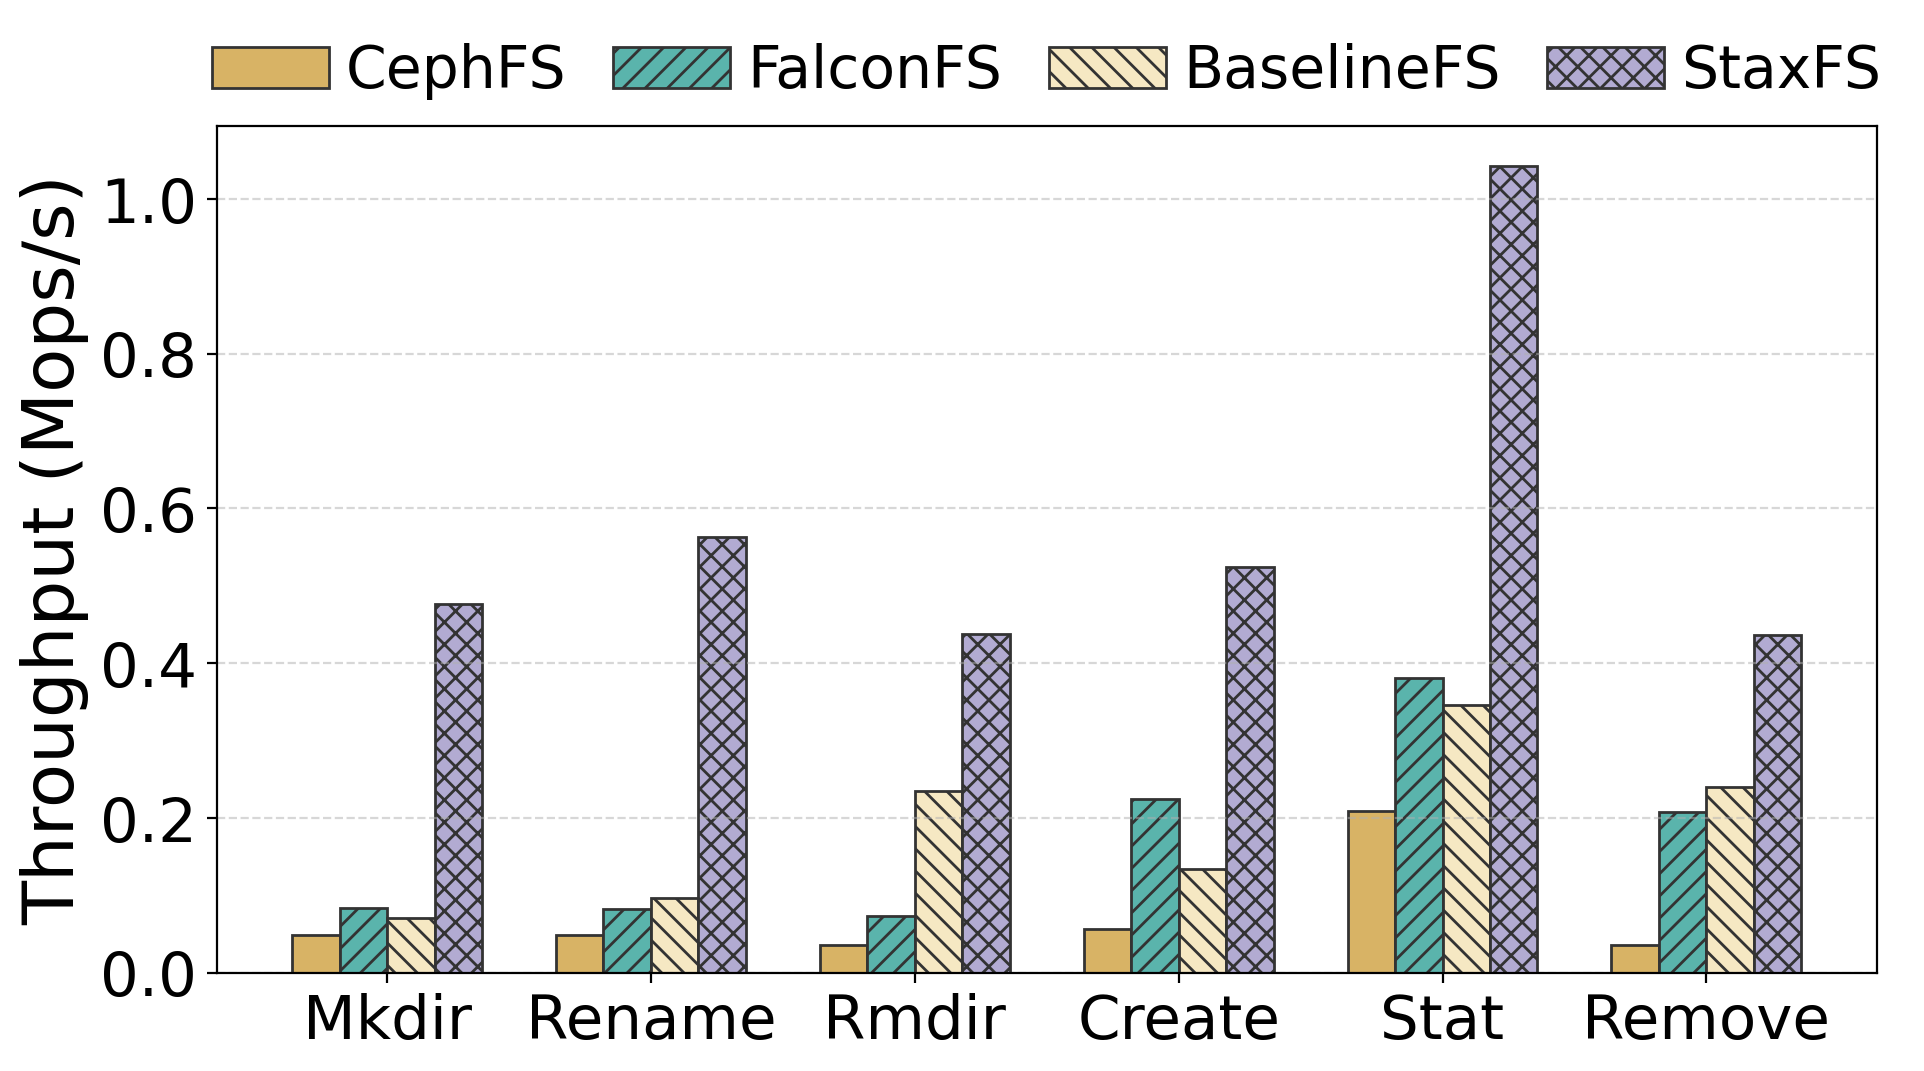

In [87]:
import matplotlib.pyplot as plt
import numpy as np

# 读取数据
data1 = {
 'Directory creation': 48125.805,
 'Directory rename': 48051.852,
 'Directory removal': 36160.471,
 'File creation': 56411.794,
 'File stat': 208821.169,
 'File removal': 36154.301}
data2 = {
 'Directory creation': 83288.865,
 'Directory rename': 82497.844,
 'Directory removal': 72854.348,
 'File creation': 224119.351,
 'File stat': 380766.847,
 'File removal': 208211.888}
data3 = read_file("../base_mdtest_5_64_3_8.log")  
data4 = read_file("../mdtest_5_64_3_8.log")  

datasets = [data1, data2, data3, data4]
configs = ["CephFS", "FalconFS", "BaselineFS", "StaxFS"]

operations = [
    'Directory creation', 'Directory rename', 'Directory removal',
    'File creation', 'File stat', 'File removal'
]
labels = ['Mkdir', 'Rename', 'Rmdir', 'Create', 'Stat', 'Remove']

# 颜色与示例图风格
# colors = ["#f6d565", "#d6e9a7", "#9cd3b3", "#7aa5d8"]
colors = [
    "#d8b365", "#5ab4ac", "#f6e8c3",
    "#b2abd2", "#8073ac", "#e08214"
]
hatches = ["", "///", "\\\\\\", "xxx"]

num_ops = len(operations)
num_cfg = len(datasets)

x = np.arange(num_ops)   # 6 个横坐标
bar_width = 0.18         # 每个柱子宽度

plt.figure(figsize=(10, 6), dpi=200)

# ======= 绘制多个配置的柱状图 =======
for cfg_idx in range(num_cfg):
    values = [datasets[cfg_idx][op] / 1_000_000 for op in operations]

    plt.bar(
        x + cfg_idx * bar_width,
        values,
        width=bar_width,
        label=configs[cfg_idx],
        color=colors[cfg_idx],
        edgecolor='0.2',
        hatch=hatches[cfg_idx]
    )

# 坐标轴标注
plt.xticks(x + bar_width * 1.5, labels, fontsize=22)
plt.yticks(fontsize=22)
plt.ylabel("Throughput (Mops/s)", fontsize=26)

# 图例放上方
plt.legend(ncol=4, fontsize=21, loc="upper center", 
           bbox_to_anchor=(0.5, 1.16), frameon=False,
           handletextpad=0.3, columnspacing=0.8)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


In [89]:
data1 = {
 'Directory creation': 2846.866,
 'Directory rename': 672.719,
 'Directory removal': 2892.262,
 'File creation': 2874.449,
 'File stat': 8882.086,
 'File removal': 2739.364}
data2 = {
 'Directory creation': 3500.195,
 'Directory rename': 2747.833,
 'Directory removal': 3006.430,
 'File creation': 6575.439,
 'File stat': 10778.152,
 'File removal': 5674.629}
data3 = read_file("../base_mdtest_1_3_8.log")  
data4 = read_file("../mdtest_1_3_8.log")  
operations = [
    'Directory creation', 'Directory rename', 'Directory removal',
    'File creation', 'File stat', 'File removal'
]
for op in operations:
    val1 = 1 / data1[op] * 1_000 * 1000
    val2 = 1 / data2[op] * 1_000 * 1000
    val3 = 1 / data3[op] * 1_000 * 1000
    val4 = 1 / data4[op] * 1_000 * 1000
    speedup_1 = val4 / val1 * 100
    speedup_2 = val4 / val2 * 100
    speedup_3 = val4 / val3 * 100
    print(f"{op}: {val1:.2f} -> {val4:.2f} ({speedup_1:.2f}/%), {val2:.2f} -> {val4:.2f} ({speedup_2:.2f}/%), {val3:.2f} -> {val4:.2f} ({speedup_3:.2f}/%)")

Directory creation: 351.26 -> 39.71 (11.30/%), 285.70 -> 39.71 (13.90/%), 166.57 -> 39.71 (23.84/%)
Directory rename: 1486.50 -> 44.16 (2.97/%), 363.92 -> 44.16 (12.14/%), 197.38 -> 44.16 (22.37/%)
Directory removal: 345.75 -> 46.76 (13.52/%), 332.62 -> 46.76 (14.06/%), 96.48 -> 46.76 (48.46/%)
File creation: 347.89 -> 39.64 (11.39/%), 152.08 -> 39.64 (26.06/%), 166.91 -> 39.64 (23.75/%)
File stat: 112.59 -> 27.76 (24.66/%), 92.78 -> 27.76 (29.92/%), 65.31 -> 27.76 (42.51/%)
File removal: 365.05 -> 46.72 (12.80/%), 176.22 -> 46.72 (26.51/%), 96.57 -> 46.72 (48.38/%)


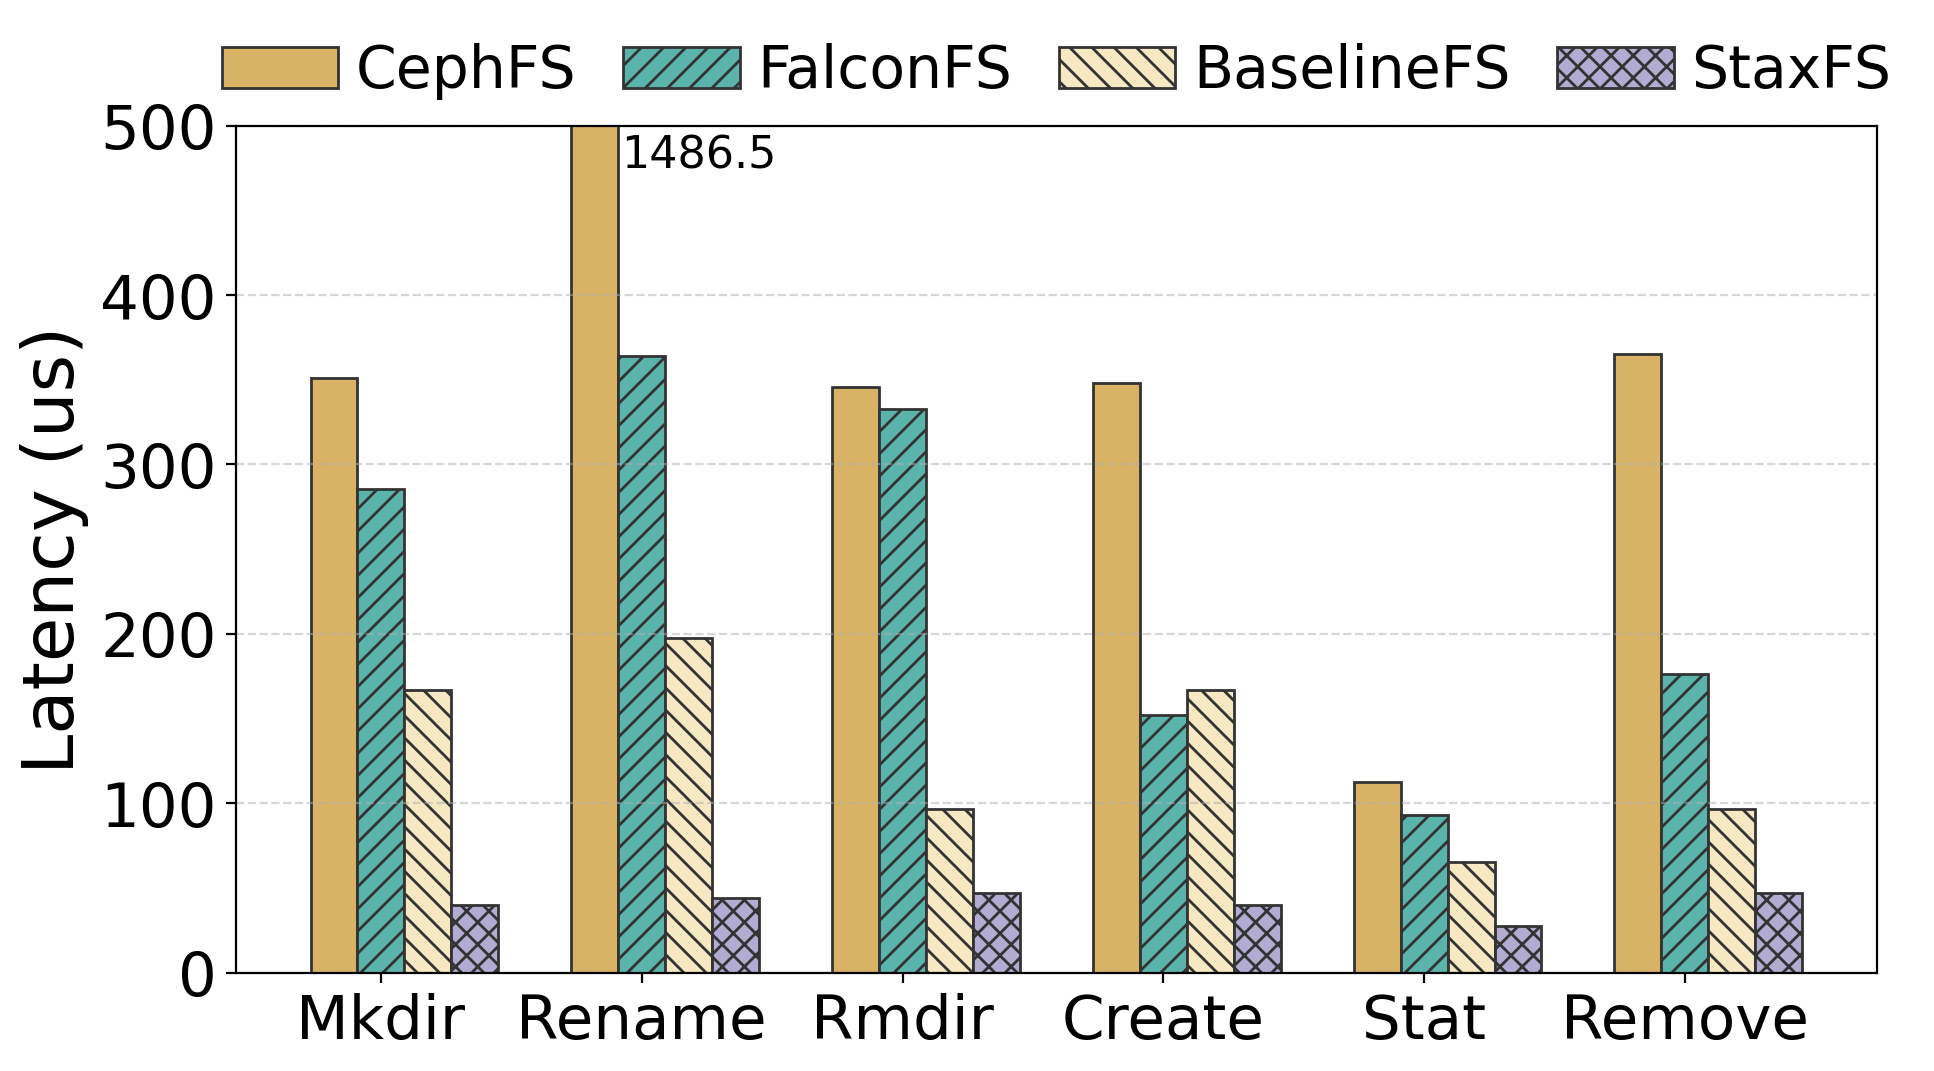

In [110]:
import matplotlib.pyplot as plt
import numpy as np

# 读取数据
data1 = {
 'Directory creation': 2846.866,
 'Directory rename': 672.719,
 'Directory removal': 2892.262,
 'File creation': 2874.449,
 'File stat': 8882.086,
 'File removal': 2739.364}
data2 = {
 'Directory creation': 3500.195,
 'Directory rename': 2747.833,
 'Directory removal': 3006.430,
 'File creation': 6575.439,
 'File stat': 10778.152,
 'File removal': 5674.629}
data3 = read_file("../base_mdtest_1_3_8.log")  
data4 = read_file("../mdtest_1_3_8.log")  

datasets = [data1, data2, data3, data4]
configs = ["CephFS", "FalconFS", "BaselineFS", "StaxFS"]

operations = [
    'Directory creation', 'Directory rename', 'Directory removal',
    'File creation', 'File stat', 'File removal'
]
labels = ['Mkdir', 'Rename', 'Rmdir', 'Create', 'Stat', 'Remove']

# 颜色与示例图风格
# colors = ["#f6d565", "#d6e9a7", "#9cd3b3", "#7aa5d8"]
colors = [
    "#d8b365", "#5ab4ac", "#f6e8c3",
    "#b2abd2", "#8073ac", "#e08214"
]
hatches = ["", "///", "\\\\\\", "xxx"]

num_ops = len(operations)
num_cfg = len(datasets)

x = np.arange(num_ops)   # 6 个横坐标
bar_width = 0.18         # 每个柱子宽度

plt.figure(figsize=(10, 6), dpi=200)

# ======= 绘制多个配置的柱状图 =======
for cfg_idx in range(num_cfg):
    values = [1 / datasets[cfg_idx][op] * 1_000 * 1000 for op in operations]

    plt.bar(
        x + cfg_idx * bar_width,
        values,
        width=bar_width,
        label=configs[cfg_idx],
        color=colors[cfg_idx],
        edgecolor='0.2',
        hatch=hatches[cfg_idx]
    )

# 坐标轴标注
plt.xticks(x + bar_width, labels, fontsize=22)
plt.yticks(fontsize=22)
plt.ylim(0, 500)
plt.ylabel("Latency (us)", fontsize=26)

plt.text(1.1, 475, "1486.5", fontsize=16, color='black')

plt.legend(ncol=4, fontsize=21, loc="upper center", 
           bbox_to_anchor=(0.5, 1.16), frameon=False,
           handletextpad=0.3, columnspacing=0.8)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


In [76]:
data1 = {
 'fileserver': 192506.848,
 'varmail': 76348.604,
 'webserver': 92060.876,
 'webproxy': 404274.084,
 'cp': 124586.342,
 'nlp': 604732.216
}
data2 = {
 'fileserver': 320859.094,
 'varmail': 244059.792,
 'webserver': 247779.173,
 'webproxy': 505159.927,
 'cp': 88002.057,
 'nlp': 334795.310 
}
data3 = {
 'fileserver': 283282.169 ,
 'varmail': 582837.174 ,
 'webserver': 645558.250 ,
 'webproxy': 428421.560,
 'cp': 194350.043,
 'nlp': 272160.993
}
data4 = {
 'fileserver': 1023676.339 ,
 'varmail': 2135452.225 ,
 'webserver': 2282278.980 ,
 'webproxy': 1599615.611,
 'cp': 1599615.611,
 'nlp': 1131015.565
}
operations = ['fileserver', 'varmail', 'webserver', 'webproxy', 'nlp', 'cp']
for op in operations:
    val1 = data1[op] / 1000
    val2 = data2[op] / 1000
    val3 = data3[op] / 1000
    val4 = data4[op] / 1000
    speedup_2 = val4 / val1
    speedup_3 = val4 / val2
    speedup_4 = val4 / val1
    print(f"{op}: {val1:.2f} -> {val4:.2f} ({speedup_2:.2f}x), {val2:.2f} -> {val4:.2f} ({speedup_3:.2f}x), {val3:.2f} -> {val4:.2f} ({speedup_4:.2f}x)")

fileserver: 192.51 -> 1023.68 (5.32x), 320.86 -> 1023.68 (3.19x), 283.28 -> 1023.68 (5.32x)
varmail: 76.35 -> 2135.45 (27.97x), 244.06 -> 2135.45 (8.75x), 582.84 -> 2135.45 (27.97x)
webserver: 92.06 -> 2282.28 (24.79x), 247.78 -> 2282.28 (9.21x), 645.56 -> 2282.28 (24.79x)
webproxy: 404.27 -> 1599.62 (3.96x), 505.16 -> 1599.62 (3.17x), 428.42 -> 1599.62 (3.96x)
nlp: 604.73 -> 1131.02 (1.87x), 334.80 -> 1131.02 (3.38x), 272.16 -> 1131.02 (1.87x)
cp: 124.59 -> 1599.62 (12.84x), 88.00 -> 1599.62 (18.18x), 194.35 -> 1599.62 (12.84x)


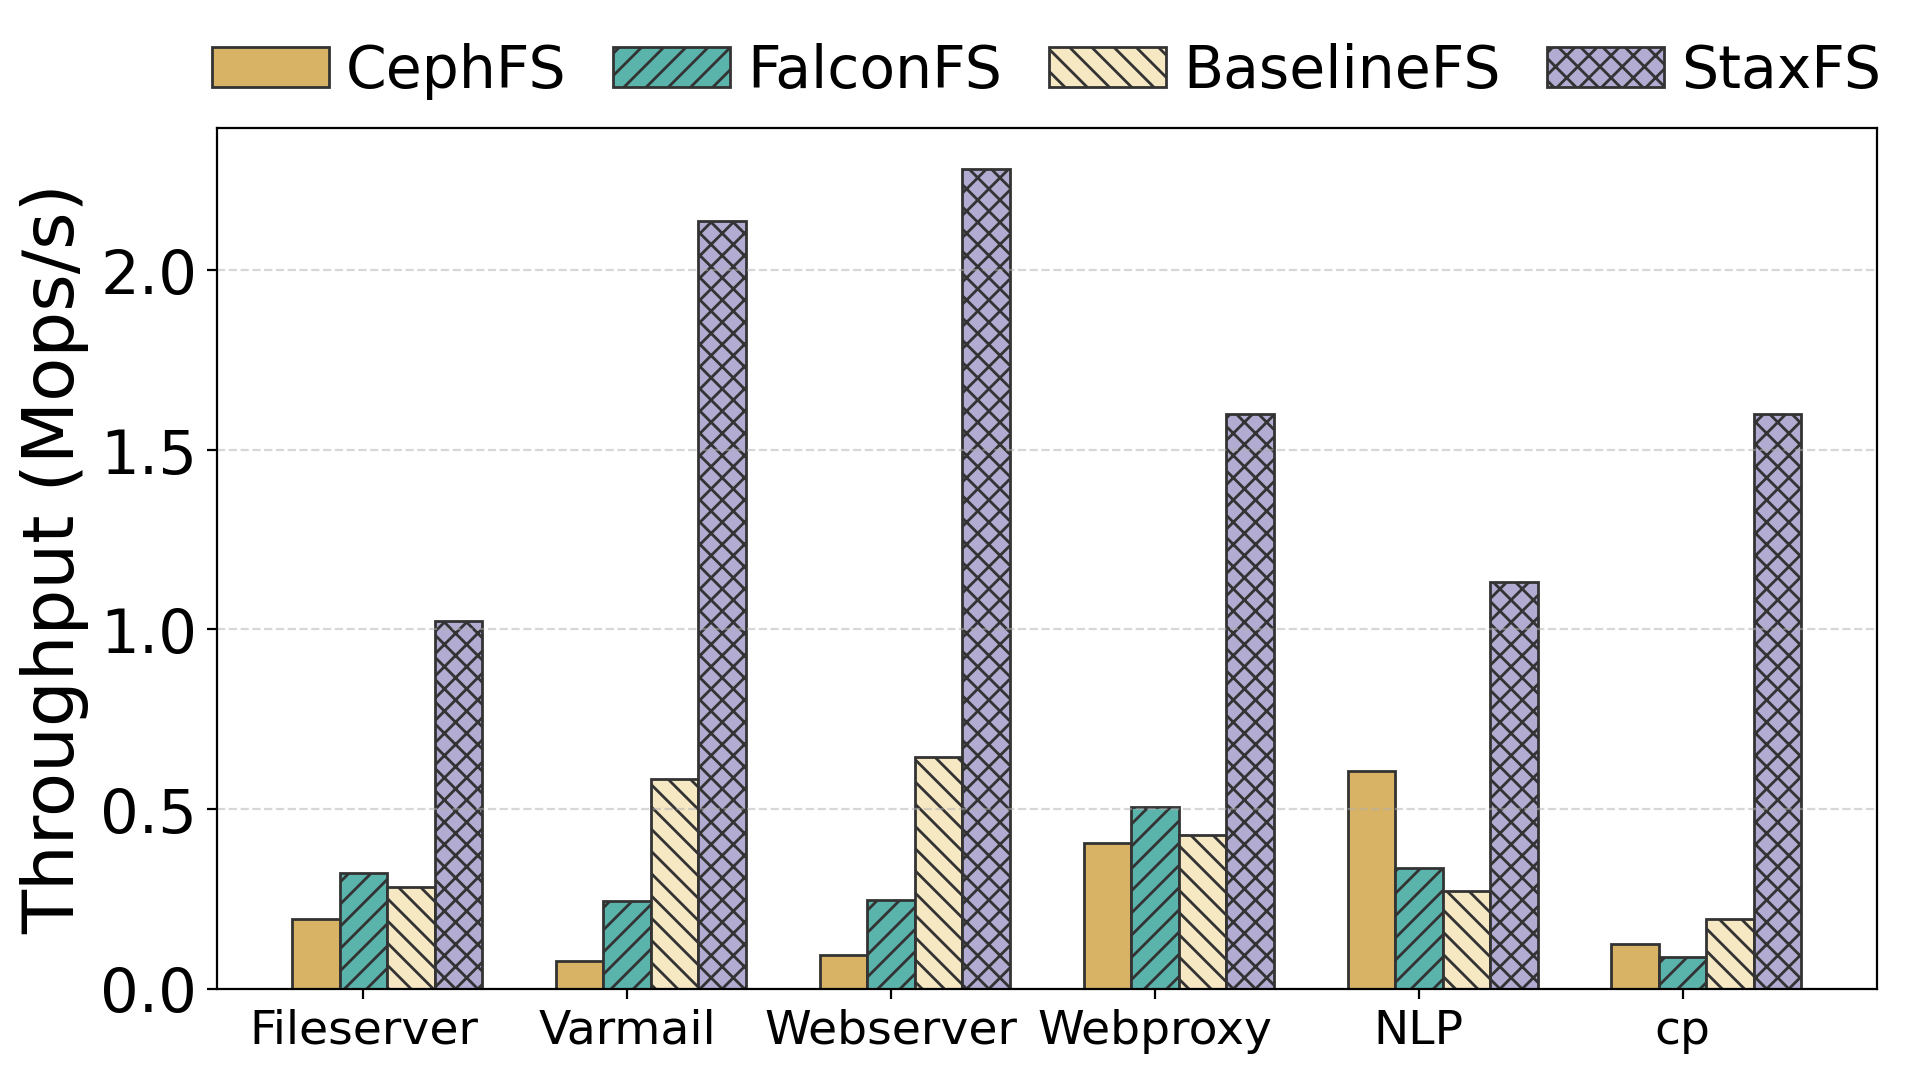

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 读取数据
data1 = {
 'fileserver': 192506.848,
 'varmail': 76348.604,
 'webserver': 92060.876,
 'webproxy': 404274.084,
 'cp': 124586.342,
 'nlp': 604732.216
}
data2 = {
 'fileserver': 320859.094,
 'varmail': 244059.792,
 'webserver': 247779.173,
 'webproxy': 505159.927,
 'cp': 88002.057,
 'nlp': 334795.310 
}
data3 = {
 'fileserver': 283282.169 ,
 'varmail': 582837.174 ,
 'webserver': 645558.250 ,
 'webproxy': 428421.560,
 'cp': 194350.043,
 'nlp': 272160.993
}
data4 = {
 'fileserver': 1023676.339 ,
 'varmail': 2135452.225 ,
 'webserver': 2282278.980 ,
 'webproxy': 1599615.611,
 'cp': 1599615.611,
 'nlp': 1131015.565
}

datasets = [data1, data2, data3, data4]
configs = ["CephFS", "FalconFS", "BaselineFS", "StaxFS"]

operations = ['fileserver', 'varmail', 'webserver', 'webproxy', 'nlp', 'cp']
labels = ['Fileserver', 'Varmail', 'Webserver', 'Webproxy', 'NLP', 'cp']

# 颜色与示例图风格
colors = [
    "#d8b365", "#5ab4ac", "#f6e8c3",
    "#b2abd2", "#8073ac", "#e08214"
]
hatches = ["", "///", "\\\\\\", "xxx"]

num_ops = len(operations)
num_cfg = len(datasets)

x = np.arange(num_ops)   # 6 个横坐标
bar_width = 0.18         # 每个柱子宽度

plt.figure(figsize=(10, 6), dpi=200)

# ======= 绘制多个配置的柱状图 =======
for cfg_idx in range(num_cfg):
    values = [datasets[cfg_idx][op] / 1_000_000 for op in operations]

    plt.bar(
        x + cfg_idx * bar_width,
        values,
        width=bar_width,
        label=configs[cfg_idx],
        color=colors[cfg_idx],
        edgecolor='0.2',
        hatch=hatches[cfg_idx]
    )

# 坐标轴标注
plt.xticks(x + bar_width, labels, fontsize=17)
plt.yticks(fontsize=22)
plt.ylabel("Throughput (Mops/s)", fontsize=26)

plt.legend(ncol=4, fontsize=21, loc="upper center", 
           bbox_to_anchor=(0.5, 1.16), frameon=False,
           handletextpad=0.3, columnspacing=0.8)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()
